# Notebook 2 of 3 -- Project Walkthrough, Part 1: Replicating an AI-first Outbound System for Realtor Leads and a Randomized Pilot Baseline

This is the second notebook in a three-part series exploring statistically rigorous marketing automation
for a realistic small-business scenario: a YouTube-focused marketing agency helping US real estate agents
("realtors") get more views, leads, and closed deals, going "AI first" for sales & marketing automation.
A plausible outbound motion for a business like this: a rule-based and/or LLM-based lead-fit score
prioritizes leads, a human setter calls the highest-priority leads, and everyone gets the same "best"
email template. This notebook replicates that system on synthetic data with **known latent truth**, then
audits it honestly against that truth.

**Important framing:** this three-notebook series is a *learning project*, not a record of prior
production experience, and not a claim that any of the three source papers were written for outbound
sales. The **pretest -> prioritize -> personalize** pipeline --
(1) pretest email variants on LLM-simulated realtors, (2) prioritize scarce setter calls with a score, (3)
personalize per-realtor template choice -- is *my own design*, not a claim sourced from the papers.
Every threshold, segment, and number below is either quoted from one of the three source papers, or
labeled **"derived here"** if it is not. Notebook 3 continues with the calibrated LLM pretest, the RATE
evaluation of the fit score, and the KPT personalization test.


## Project scope

The idea here is an **audit-and-upgrade harness for a lead-scoring + outbound-messaging pipeline**,
built in three notebooks:

1. Replicate a plausible current system at small scale: a free rule-based fit score, an "AI first" LLM
 fit score read off each lead's bio, a human setter who calls the highest-priority leads, and a single
 "best" email template sent to everyone.
2. Build a **known-ground-truth synthetic lead generator** (this notebook, `## 1`) so every later claim
 about targeting quality, uplift, or personalization gain is checkable against a fact about the
 generator, not just plausible-sounding.
3. Run this notebook's **randomized Month-1 pilot** (`## 3`) -- the data every downstream causal claim in
 Notebook 3 rests on -- and an honest **baseline audit** (`## 4`) of what the client's dashboard would
 show today versus what the latent truth actually says.
4. Notebook 3 picks up the three methods this pipeline is built around: a calibrated LLM pretest of email
 variants (surrogacy), a RATE evaluation of whether the fit score actually tracks call *uplift* (not just
 baseline booking odds), and a KPT test of whether per-lead template personalization beats sending
 everyone the single best template.

The eventual deliverable I'm working toward is **not** built in this notebook: a written
recommendation on where to move the setter-call cutoff, whether to personalize templates, and how much of
the "AI-first" system's own targeting is actually working.


## Dataset rationale

Real stand-ins I could swap in later, in rough order of realism:

- **Their own CRM export**, e.g. a HubSpot or GoHighLevel pipeline of realtor leads with call outcomes and
 email engagement already logged -- the natural fit, since it would already carry the setter-call and
 email-template history this notebook simulates.
- **Public realtor license rosters** (state real-estate commission license lookups) for firmographic
 covariates (years licensed, brokerage) with no outcome data attached -- useful for the covariate side
 only, not for the causal side.
- The **Criteo Uplift dataset**, the public randomized-experiment analogue actually used in RATE's own
 marketing application (Table 5): "Evaluating targeting rules on Criteo's benchmark dataset using
 320,000 balanced samples (160,000 train, 160,000 test)" with a visit/conversion outcome and a randomized
 treatment indicator -- structurally the closest public dataset to "randomized outbound treatment with a
 binary conversion-like outcome," even though it is display-ad traffic, not realtor leads.

**None of these are downloaded here.** The reason is specific to what this notebook needs to measure:
checking whether a fit score tracks *uplift* rather than *baseline outcome* (`## 4`), and whether template
personalization beats the single best template (`## 1`'s psi, continued with KPT in Notebook 3), both
require **known potential outcomes** -- the true booking probability with and without a call, and the true
reply probability under each template, for the same lead. No real dataset has that. Instead, `## 1` below
builds a **synthetic generator with known latent truth**: every lead is stamped with its `true_` potential
outcomes at generation time, by construction, so every claim about "the honest version of the dashboard"
(`## 4`) or "money left on the table" is a fact about the generator, checkable in this notebook, rather than
an unverifiable claim about the real world. Swapping in a real CRM export later means losing the `true_`
columns and gaining the harder, real problem of estimating them.


In [1]:
%matplotlib inline
import hashlib
import json
import math
import os
import re
import threading
import time
import urllib.error
import urllib.request
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel, ConfigDict, ValidationError
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

SEED = 20260917
RNG = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data"
CACHE_DIR = DATA_DIR / "llm_cache" / "deepseek"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Single palette dict reused by every chart in this notebook.
PALETTE = {
    "persuadable_growth": "#1f77b4",
    "sure_thing_inbound": "#2ca02c",
    "lost_cause_parttime": "#7f7f7f",
    "do_not_disturb_media_team": "#d62728",
    "hidden_gem_sparse_bio": "#9467bd",
    "ambiguous_team_member": "#ff7f0e",
    "tmpl0_generic_case_study": "#1f77b4",
    "tmpl1_market_data_hook": "#ff7f0e",
    "tmpl2_video_audit_teaser": "#2ca02c",
    "p0": "#7f7f7f",
    "uplift_pos": "#2ca02c",
    "uplift_neg": "#d62728",
    "called": "#1f77b4",
    "not_called": "#7f7f7f",
    "rule_score": "#1f77b4",
    "llm_score": "#9467bd",
    "true_uplift_rule": "#1f77b4",
    "true_uplift_llm": "#9467bd",
    "true_uplift_oracle": "#2ca02c",
    "true_uplift_random": "#7f7f7f",
}


def wilson_ci(k, n, z=1.959963985):
    """Wilson score interval for a binomial proportion k/n. Returns (lo, phat, hi). Derived here."""
    if n == 0:
        return (float("nan"),) * 3
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return center - half, phat, center + half


def mean_ci(x, z=1.959963985):
    """Normal-approximation CI for a sample mean. Derived here."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    se = x.std(ddof=1) / math.sqrt(n)
    return m - z * se, m, m + z * se


def newcombe_diff_ci(k1, n1, k0, n0):
    """Newcombe (1998) hybrid-score CI for a difference of two independent proportions,
    built from the two Wilson intervals. Derived here."""
    l1, p1, u1 = wilson_ci(k1, n1)
    l0, p0, u0 = wilson_ci(k0, n0)
    diff = p1 - p0
    lo = diff - math.sqrt((p1 - l1) ** 2 + (u0 - p0) ** 2)
    hi = diff + math.sqrt((u1 - p1) ** 2 + (p0 - l0) ** 2)
    return lo, diff, hi


def fmt_ci(lo, mid, hi, pct=True):
    if pct:
        return f"{mid*100:.2f}% (95% CI [{lo*100:.2f}%, {hi*100:.2f}%])"
    return f"{mid:.4f} (95% CI [{lo:.4f}, {hi:.4f}])"


## 1. Synthetic realtor lead generator with known latent truth

None of the three source papers describe a realtor-outreach data-generating process -- the
**pretest -> prioritize -> personalize pipeline is this project's design, not a sourced claim**. What
the papers *do* supply is the formal setup each later step needs: RATE needs iid `(X_i, Y_i, W_i)` with
potential outcomes `{Y_i(0), Y_i(1)}` and CATE `tau(x) = E[Y_i(1) - Y_i(0) | X_i = x]` (Eq. 2.1); the
surrogacy paper needs a randomized `W in {0,1}` arm with human outcome `Y(W)`; KPT needs
`(X_i, A_i, Y_i)` with a known action distribution `p(a|x)`. `generate_leads(n, seed)` below builds
exactly that: ~6,000 synthetic US realtors with **both** potential outcomes stamped at generation time
(`true_p0`, `true_p1`, `true_call_uplift` for the setter-call decision; `true_reply_p_tmpl{0,1,2}` for the
email-template decision) so every claim later in this notebook is checkable against the generator, not an
estimate.

**Six latent segments** (`true_segment`), all **derived here**, deliberately including cases that are hard
to define or hard to read off a bio:

- `persuadable_growth` -- mid-volume producer, active on social, no video presence yet: low booking odds
 without a call, big uplift from one.
- `sure_thing_inbound` -- came in through an inbound form already asking about video help: books at a high
 rate whether or not a setter calls (near-zero uplift).
- `lost_cause_parttime` -- low-activity part-time agent: low booking odds either way.
- `do_not_disturb_media_team` -- top producer or team lead who already has an in-house videographer: a call
 reads as a nuisance, **negative** uplift.
- `hidden_gem_sparse_bio` -- same underlying profile as `persuadable_growth`, but its bio's cue sentences
 (video interest, activity, etc.) fire at lower probability than `persuadable_growth`'s do, and it shares
 the same population-wide terseness rate as every other segment rather than a special one -- a
 definition-hard case built specifically to be hard, on average, for a text-reading LLM fit score
 (Section 2) to catch, without making any single bio a deterministic tell.
- `ambiguous_team_member` -- a "media-team" bio cue (in-house videographer / team channel language) fires
 for this segment noticeably more often than for most others, even though this individual has no personal
 video presence: moderate uplift, another case built to be easy to mis-read from text alone.

Two separate outcomes are simulated per lead: `booked_call` within 14 days (driven by the setter-call
treatment `W`), and `positive_reply` within 7 days (driven by which of three email templates -- written out
in full below -- the lead receives). The template effect is heterogeneous by design (video-audit teasers
work best for realtors who already have *some* YouTube presence; market-data hooks work best for
high-producing realtors with no video; the generic case study works best for already-inbound leads), which
is what makes a positive personalization effect `psi` possible at all -- computed below by exhaustive search
over the depth-<=2 policy class, the same object KPT's `psi:= max_pi V(pi) - max_a U(a)` (Eq. 1 / S1)
targets, evaluated here on the population rather than estimated from a sample (that estimation step is
Notebook 3's job).

**Within-segment heterogeneity is real, not just between-segment.** `true_call_uplift` is segment base +
a smooth function of observed features (social activity, deals, tenure, metro tier, YouTube presence/size,
centered within segment so segment *means* are unaffected) + idiosyncratic, unobservable noise, then
clipped -- so two leads in the same segment do not have identical uplift (checked at [1.10]/[1.11] below).
Template reply probabilities get the same treatment: continuous, saturating feature effects plus
per-(lead, template) noise, rather than one of a handful of identical values shared by every lead with the
same three coarse features. Bios are built from independent, probabilistic cue sentences (Section 2) rather
than one fixed signature sentence per segment, so no bio is a deterministic tell for its segment -- checked
directly at [1.12] with a held-out bag-of-words classifier.


In [2]:
# ============================================================================
# Synthetic realtor lead generator with known latent truth. Every number here
# (segment shares, potential-outcome probabilities, template effects) is
# **derived here** for this project -- not sourced from any of the
# three papers, which is the point: the papers evaluate scores/policies on
# outcomes, they do not supply a realtor-industry data generating process.
# ============================================================================

FIRST_NAMES = [
    "Maria", "James", "Aisha", "Wei", "Carlos", "Emily", "David", "Priya",
    "Robert", "Sofia", "Michael", "Linda", "Kevin", "Grace", "Daniel", "Nina",
    "Brian", "Yolanda", "Tom", "Fatima", "Andre", "Julia", "Marcus", "Chen",
]

METRO_LABEL = {"tier1": "a major metro", "tier2": "a mid-size metro", "tier3": "a smaller market"}

SEGMENTS = [
    "persuadable_growth", "sure_thing_inbound", "lost_cause_parttime",
    "do_not_disturb_media_team", "hidden_gem_sparse_bio", "ambiguous_team_member",
]
# Population shares (derived here). Sum to 1.
SEG_SHARE = {
    "persuadable_growth": 0.22, "sure_thing_inbound": 0.10, "lost_cause_parttime": 0.20,
    "do_not_disturb_media_team": 0.12, "hidden_gem_sparse_bio": 0.14, "ambiguous_team_member": 0.22,
}
# Baseline (no-call) booking probability and additive call uplift per segment (derived here).
SEG_P0 = {
    "persuadable_growth": 0.03, "sure_thing_inbound": 0.30, "lost_cause_parttime": 0.02,
    "do_not_disturb_media_team": 0.10, "hidden_gem_sparse_bio": 0.03, "ambiguous_team_member": 0.05,
}
SEG_UPLIFT = {
    "persuadable_growth": 0.14, "sure_thing_inbound": 0.01, "lost_cause_parttime": 0.01,
    "do_not_disturb_media_team": -0.04, "hidden_gem_sparse_bio": 0.13, "ambiguous_team_member": 0.06,
}

SEGMENT_BLURB = {
    "persuadable_growth": "mid-volume producer, active on social, no video presence yet -- low odds of booking without a human nudge, but a setter call moves the needle a lot",
    "sure_thing_inbound": "came in through an inbound form already asking about video help -- books at a high rate whether or not a setter calls",
    "lost_cause_parttime": "low-activity part-time agent -- low odds of booking with or without a call",
    "do_not_disturb_media_team": "top producer or team lead who already has an in-house videographer -- a call can read as a nuisance and slightly lower booking odds",
    "hidden_gem_sparse_bio": "same profile as persuadable_growth underneath, but the bio text gives almost nothing away -- hard for a text-reading model to catch",
    "ambiguous_team_member": "bio mentions the team's YouTube channel, but this individual has no personal video presence -- moderate uplift from a call",
}

EMAIL_TEMPLATES = {
    0: {
        "name": "generic_case_study",
        "subject": "How {sample_agent} in {sample_metro} added 6 closings from YouTube",
        "body": (
            "Hi {first_name},\n\n"
            "We work with residential agents across the country who wanted more listing "
            "and buyer leads without spending more on ads. One agent we partnered with, "
            "roughly at your production level, went from a dormant channel to consistently "
            "booked showings in about four months by publishing one neighborhood-market "
            "video a week and letting our team handle editing and thumbnails end to end.\n\n"
            "We put together a short case study on how that rollout worked, including the "
            "publishing cadence and what it cost per closing. Want me to send it over?\n\n"
            "Best,\nThe Agency Team"
        ),
    },
    1: {
        "name": "market_data_hook",
        "subject": "{metro_label} inventory data your buyers haven't seen yet",
        "body": (
            "Hi {first_name},\n\n"
            "We just finished pulling a fresh inventory and days-on-market breakdown for "
            "{metro_label}, and a few numbers in it would make a strong short-form video for "
            "an agent at your production level -- {deals} deals over the last year is well "
            "above the median in your market. Video is the fastest way we've seen experienced "
            "producers turn that kind of track record into inbound calls instead of only "
            "referrals.\n\n"
            "Happy to send the data breakdown either way, no obligation. Interested?\n\n"
            "Best,\nThe Agency Team"
        ),
    },
    2: {
        "name": "video_audit_teaser",
        "subject": "Quick teardown of your channel, {first_name}?",
        "body": (
            "Hi {first_name},\n\n"
            "I took a quick look at your YouTube presence -- there's real upside in a channel "
            "your size that most agents don't unlock: better thumbnails, a consistent posting "
            "cadence, and a stronger hook in your first eight seconds go a long way. We do a "
            "free 5-minute video-by-video teardown for agents actively posting, no strings "
            "attached, and most people are surprised how much is fixable without shooting more "
            "footage.\n\n"
            "Want us to send the teardown for your channel?\n\n"
            "Best,\nThe Agency Team"
        ),
    },
}
TEMPLATE_ORDER = [0, 1, 2]
TEMPLATE_NAMES = {a: EMAIL_TEMPLATES[a]["name"] for a in TEMPLATE_ORDER}


def render_template(template_id: int, lead: dict) -> str:
    t = EMAIL_TEMPLATES[template_id]
    ctx = {
        "first_name": lead["agent_first_name"],
        "metro_label": METRO_LABEL[lead["metro_tier"]].capitalize(),
        "deals": lead["deals_last_12m"],
        "sample_agent": "Jordan R.",
        "sample_metro": "a mid-size metro",
    }
    return f"Subject: {t['subject'].format(**ctx)}\n\n{t['body'].format(**ctx)}"


# --- Bio cue system (revised) ---------------------------------------------
# Bios are built from cue sentences, each emitted with a PROBABILITY that
# depends on features/segment, deliberately overlapping across segments, so
# that no single sentence is a deterministic tell for any one segment. This
# replaces an earlier version where each segment had its own signature
# sentence (a leakage bug I caught on review) --
# the [1.12] bag-of-words leakage self-check below is the check that catches
# a regression back to that failure mode.
VIDEO_INTEREST_P = {  # mentions interest in video/YouTube help
    "persuadable_growth": 0.15, "sure_thing_inbound": 0.40, "lost_cause_parttime": 0.05,
    "do_not_disturb_media_team": 0.03, "hidden_gem_sparse_bio": 0.08, "ambiguous_team_member": 0.10,
}
MEDIA_TEAM_P = {  # mentions an in-house videographer / existing media support
    "persuadable_growth": 0.05, "sure_thing_inbound": 0.05, "lost_cause_parttime": 0.03,
    "do_not_disturb_media_team": 0.55, "hidden_gem_sparse_bio": 0.05, "ambiguous_team_member": 0.15,
}
TERSE_P = 0.28          # same terseness rate for every segment (20-35% band)
MISLEADING_P = 0.15     # lost_cause_parttime only: a misleading "wants to grow" cue
DEALS_MENTION_P = 0.70
LEAD_SOURCE_MENTION_P = 0.50

VIDEO_INTEREST_SENTENCES = [
    "Recently asked about getting started with video for listings.",
    "Mentioned wanting help building out a YouTube presence.",
    "Has been thinking about trying short-form video content.",
]
MEDIA_TEAM_SENTENCES = [
    "Works with an in-house videographer on a regular posting schedule.",
    "The team already runs a YouTube channel with a dedicated media hire.",
    "Has some in-house support for producing video content.",
]
ACTIVE_SOCIAL_SENTENCES = [
    "Posts on Instagram regularly.",
    "Keeps up an active social media presence.",
    "Shares listings and updates on social media often.",
]
LEAD_SOURCE_SENTENCES = {
    "inbound_form": ["Reached out directly through our website.", "Filled out our contact form."],
    "cold_list": ["Sourced from a purchased contact list.", "Added from an outreach list."],
    "webinar": ["Attended one of our marketing webinars.", "Signed up after a webinar."],
}
MISLEADING_SENTENCES = [
    "Says they want to grow the business this year.",
    "Mentioned wanting to take things to the next level this year.",
]
OPENER_POOL = [
    "{name} is a licensed agent in {metro} with {years} years in the business.",
    "{name} has been licensed for {years} years, working in {metro}.",
    "Based in {metro}, {name} has {years} years of experience.",
]
TERSE_POOL = [
    "{name} is a realtor in {metro}.",
    "{name} is a licensed agent with {years} years in the business.",
    "Realtor based in {metro}.",
]


def build_bio(rng, seg, row) -> str:
    name = row["agent_first_name"]
    metro = METRO_LABEL[row["metro_tier"]]
    years = row["years_licensed"]
    deals = row["deals_last_12m"]

    if rng.random() < TERSE_P:
        return rng.choice(TERSE_POOL).format(name=name, metro=metro, years=years)

    parts = [rng.choice(OPENER_POOL).format(name=name, metro=metro, years=years)]
    if rng.random() < DEALS_MENTION_P:
        parts.append(f"Closed {deals} deals in the last 12 months.")
    if rng.random() < VIDEO_INTEREST_P[seg]:
        parts.append(rng.choice(VIDEO_INTEREST_SENTENCES))
    if rng.random() < MEDIA_TEAM_P[seg]:
        parts.append(rng.choice(MEDIA_TEAM_SENTENCES))
    active_social_p = float(np.clip(row["ig_posts_per_month"] / 25.0, 0.03, 0.85))
    if rng.random() < active_social_p:
        parts.append(rng.choice(ACTIVE_SOCIAL_SENTENCES))
    if rng.random() < LEAD_SOURCE_MENTION_P:
        parts.append(rng.choice(LEAD_SOURCE_SENTENCES[row["lead_source"]]))
    if seg == "lost_cause_parttime" and rng.random() < MISLEADING_P:
        parts.append(rng.choice(MISLEADING_SENTENCES))
    return " ".join(parts)


def generate_leads(n: int, seed: int) -> pd.DataFrame:
    """Generate n synthetic realtor leads with known latent truth. Deterministic given seed."""
    rng = np.random.default_rng(seed)
    segs = rng.choice(SEGMENTS, size=n, p=[SEG_SHARE[s] for s in SEGMENTS])
    metro_tier = rng.choice(["tier1", "tier2", "tier3"], size=n, p=[0.3, 0.4, 0.3])
    years_licensed = rng.integers(1, 26, size=n)
    agent_first_name = rng.choice(FIRST_NAMES, size=n)

    deals = np.zeros(n, dtype=int)
    has_youtube = np.zeros(n, dtype=bool)
    yt_subs = np.zeros(n, dtype=int)
    lead_source = np.empty(n, dtype=object)
    team_role = np.empty(n, dtype=object)
    videos_90d = np.zeros(n, dtype=int)
    ig_posts = np.zeros(n, dtype=int)

    for i, s in enumerate(segs):
        if s == "persuadable_growth":
            deals[i] = rng.integers(5, 20)
            ig_posts[i] = rng.integers(6, 20)
            team_role[i] = rng.choice(["solo", "team_member"])
            lead_source[i] = rng.choice(["cold_list", "webinar"], p=[0.6, 0.4])
        elif s == "sure_thing_inbound":
            deals[i] = rng.integers(3, 20)
            has_youtube[i] = rng.random() < 0.3
            yt_subs[i] = rng.integers(0, 500) if has_youtube[i] else 0
            ig_posts[i] = rng.integers(2, 15)
            team_role[i] = rng.choice(["solo", "team_member"])
            lead_source[i] = "inbound_form"
        elif s == "lost_cause_parttime":
            deals[i] = rng.integers(0, 4)
            ig_posts[i] = rng.integers(0, 4)
            team_role[i] = "solo"
            lead_source[i] = rng.choice(["cold_list", "webinar"], p=[0.8, 0.2])
        elif s == "do_not_disturb_media_team":
            deals[i] = rng.integers(16, 40)
            has_youtube[i] = True
            yt_subs[i] = rng.integers(3000, 30000)
            videos_90d[i] = rng.integers(8, 30)
            ig_posts[i] = rng.integers(10, 30)
            team_role[i] = "team_lead"
            lead_source[i] = rng.choice(["cold_list", "webinar"], p=[0.7, 0.3])
        elif s == "hidden_gem_sparse_bio":
            deals[i] = rng.integers(5, 20)
            ig_posts[i] = rng.integers(4, 18)
            team_role[i] = rng.choice(["solo", "team_member"])
            lead_source[i] = rng.choice(["cold_list", "webinar"], p=[0.6, 0.4])
        else:  # ambiguous_team_member
            deals[i] = rng.integers(3, 18)
            ig_posts[i] = rng.integers(2, 12)
            team_role[i] = "team_member"
            lead_source[i] = rng.choice(["cold_list", "webinar"], p=[0.6, 0.4])

    fill_videos = rng.integers(0, 8, size=n)
    fill_subs = rng.integers(50, 3000, size=n)
    videos_90d = np.where(has_youtube & (videos_90d == 0), fill_videos, videos_90d)
    yt_subs = np.where(has_youtube & (yt_subs == 0), fill_subs, yt_subs)

    df = pd.DataFrame({
        "lead_id": [f"L{seed % 100000:05d}{i:06d}" for i in range(n)],
        "true_segment": segs, "agent_first_name": agent_first_name, "metro_tier": metro_tier,
        "years_licensed": years_licensed, "deals_last_12m": deals, "team_role": team_role,
        "has_youtube": has_youtube, "yt_subscribers": yt_subs, "videos_last_90d": videos_90d,
        "ig_posts_per_month": ig_posts, "lead_source": lead_source,
    })
    df["deals_bucket"] = pd.cut(df["deals_last_12m"], bins=[-1, 4, 14, 10_000],
                                 labels=["low", "mid", "high"])

    # --- bios ---
    bio_rng = np.random.default_rng(seed + 1)
    df["bio"] = [build_bio(bio_rng, seg, row) for seg, (_, row) in zip(segs, df.iterrows())]

    # --- potential outcomes: booked_call under no-call (p0) / call (p1) ---
    def logit(p):
        return np.log(p / (1 - p))

    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    out_rng = np.random.default_rng(seed + 2)
    seg_p0 = df["true_segment"].map(SEG_P0).to_numpy()
    seg_up = df["true_segment"].map(SEG_UPLIFT).to_numpy()
    jitter0 = out_rng.normal(0, 0.25, size=n)
    p0 = sigmoid(logit(np.clip(seg_p0, 0.005, 0.995)) + jitter0)
    p0 = np.clip(p0, 0.005, 0.9)

    # Uplift is now genuinely heterogeneous WITHIN segment: segment base + a smooth
    # function of observed features (centered per segment so segment MEANS stay put,
    # only within-segment dispersion is added) + idiosyncratic, unobservable noise.
    # This replaces a prior version where true_call_uplift was an exact per-segment
    # constant (std 0.000) -- a leakage/over-easy bug I caught on review.
    metro_bump = df["metro_tier"].map({"tier1": -0.005, "tier2": 0.0, "tier3": 0.008}).to_numpy()
    yt_term = np.where(df["has_youtube"].to_numpy(), -0.000003 * df["yt_subscribers"].to_numpy(), 0.0)
    feat_term = (
        0.0008 * (df["ig_posts_per_month"].to_numpy() - 10)
        - 0.0004 * (df["deals_last_12m"].to_numpy() - 10)
        - 0.0008 * (df["years_licensed"].to_numpy() - 10)
        + metro_bump + yt_term
    )
    feat_term_centered = feat_term - pd.Series(feat_term).groupby(segs).transform("mean").to_numpy()
    eps_uplift = out_rng.normal(0, 0.045, size=n)  # idiosyncratic, unobservable, ~4.5pp sd
    uplift_nominal = seg_up + feat_term_centered + eps_uplift
    p1 = np.clip(p0 + uplift_nominal, 0.005, 0.95)
    df["true_p0"] = p0
    df["true_p1"] = p1
    df["true_call_uplift"] = p1 - p0

    # --- potential outcomes: positive_reply by template. Continuous, saturating
    # feature effects (not step functions on discretized buckets) plus per-(lead,
    # template) idiosyncratic noise give real within-cell heterogeneity, instead of
    # every lead sharing one of ~18 identical (has_youtube, deals_bucket, lead_source)
    # reply-probability profiles -- another over-easy pattern flagged in review.
    inbound = df["lead_source"] == "inbound_form"
    base = 0.10
    tmpl_main = {0: 0.0, 1: -0.017, 2: -0.024}
    reply_rng = np.random.default_rng(seed + 3)
    reply_p = np.zeros((n, 3))
    for a in TEMPLATE_ORDER:
        reply_p[:, a] = base + tmpl_main[a]
    yt_boost = 0.06 * np.clip(df["yt_subscribers"].to_numpy() / 2000.0, 0, 1) * df["has_youtube"].to_numpy()
    deals_boost = 0.05 * np.clip((df["deals_last_12m"].to_numpy() - 8) / 15.0, 0, 1) * (~df["has_youtube"]).to_numpy()
    inbound_boost = 0.03 * inbound.to_numpy().astype(float)
    reply_p[:, 2] += yt_boost
    reply_p[:, 1] += deals_boost
    reply_p[:, 0] += inbound_boost
    reply_noise = reply_rng.normal(0, 0.02, size=(n, 3))  # idiosyncratic per (lead, template)
    reply_p = np.clip(reply_p + reply_noise, 0.01, 0.5)
    for a in TEMPLATE_ORDER:
        df[f"true_reply_p_tmpl{a}"] = reply_p[:, a]

    return df


def best_single_template(df: pd.DataFrame) -> tuple[int, float, float]:
    """Population-average reply rate by template; returns (best_id, best_rate, gap_to_2nd_pp)."""
    avgs = np.array([df[f"true_reply_p_tmpl{a}"].mean() for a in TEMPLATE_ORDER])
    order = np.argsort(avgs)[::-1]
    gap_pp = (avgs[order[0]] - avgs[order[1]]) * 100
    return int(order[0]), float(avgs[order[0]]), float(gap_pp)


def true_personalization_psi(df: pd.DataFrame) -> dict:
    """Exhaustive search of the true psi (Eq. S1-style, derived here) over the depth<=2 policy
    class using single features and feature pairs from (has_youtube, deals_bucket, lead_source).
    Returns a dict with U(a*), V(pi*) and psi = V(pi*) - U(a*)."""
    n = len(df)
    r = np.stack([df[f"true_reply_p_tmpl{a}"].to_numpy() for a in TEMPLATE_ORDER], axis=1)
    u_star = r.mean(axis=0).max()

    feats = {
        "has_youtube": df["has_youtube"].astype(str).to_numpy(),
        "deals_bucket": df["deals_bucket"].astype(str).to_numpy(),
        "lead_source": df["lead_source"].to_numpy(),
    }

    def value_of(cols):
        keys = list(zip(*[feats[c] for c in cols])) if len(cols) > 1 else list(feats[cols[0]])
        tmp = pd.Series(keys)
        total = 0.0
        for _, idx in tmp.groupby(tmp).groups.items():
            pos = df.index.get_indexer(idx)
            sub = r[pos]
            best_a = sub.mean(axis=0).argmax()
            total += sub[:, best_a].sum()
        return total / n

    candidates = {"single_arm": u_star}
    for c in feats:
        candidates[f"depth1:{c}"] = value_of([c])
    for c1, c2 in combinations(feats, 2):
        candidates[f"depth2:{c1}+{c2}"] = value_of([c1, c2])
    best_policy = max(candidates, key=candidates.get)
    v_star = candidates[best_policy]
    return {"U_a_star": u_star, "V_pi_star": v_star, "psi": v_star - u_star,
            "best_policy": best_policy, "candidates": candidates}


In [3]:
POPULATION = generate_leads(6000, SEED)

print("The three email templates (rendered for one example lead):\n")
for a in TEMPLATE_ORDER:
    print(f"--- template {a}: {TEMPLATE_NAMES[a]} ---")
    print(render_template(a, POPULATION.iloc[0].to_dict()))
    print()

seg_counts = POPULATION["true_segment"].value_counts()
n_pop = len(POPULATION)
print("Segment shares (population, n={}):".format(n_pop))
for seg in SEGMENTS:
    k = int(seg_counts.get(seg, 0))
    lo, phat, hi = wilson_ci(k, n_pop)
    target = SEG_SHARE[seg]
    ok = lo <= target <= hi
    print(f"  [1.1.{seg}] share={fmt_ci(lo, phat, hi)} target={target*100:.0f}% -> {'PASS' if ok else 'FAIL'}")

lo, mid, hi = mean_ci(POPULATION["true_p0"])
print(f"[1.2] mean true_p0 (uncalled booking rate) = {fmt_ci(lo, mid, hi)}, target ~6% -> "
      f"{'PASS' if 0.04 <= mid <= 0.09 else 'FAIL'}")
lo, mid, hi = mean_ci(POPULATION["true_p1"])
print(f"[1.3] mean true_p1 (called booking rate) = {fmt_ci(lo, mid, hi)}, target 11-13% -> "
      f"{'PASS' if 0.10 <= mid <= 0.14 else 'FAIL'}")
lo, mid, hi = mean_ci(POPULATION["true_call_uplift"])
print(f"[1.4] mean true call ATE = {fmt_ci(lo, mid, hi)} -> {'PASS' if mid > 0 else 'FAIL'}")

dnd_uplift = POPULATION.loc[POPULATION["true_segment"] == "do_not_disturb_media_team", "true_call_uplift"]
lo, mid, hi = mean_ci(dnd_uplift)
print(f"[1.5] do_not_disturb_media_team mean uplift = {fmt_ci(lo, mid, hi)}, expect < 0 -> "
      f"{'PASS' if hi < 0 else 'FAIL'}")
dnd_pos_share = (dnd_uplift > 0).mean()
print(f"      (informational) share of do_not_disturb leads with individually POSITIVE realized "
      f"uplift, despite the negative mean = {dnd_pos_share*100:.1f}% -- 'mostly but not uniformly negative'")

# [1.6] near-zero uplift, checked at the SEGMENT-DESIGN level (stable under added
# within-segment noise): sure_thing_inbound and lost_cause_parttime are the two
# segments designed to have ~0 mean uplift.
near_zero_segs = [s for s in SEGMENTS if abs(SEG_UPLIFT[s]) <= 0.02]
near_zero_share_design = sum(SEG_SHARE[s] for s in near_zero_segs)
print(f"[1.6] segments with |mean uplift| <= 2pp by design ({near_zero_segs}) = "
      f"{near_zero_share_design*100:.1f}% of population, expect >= 25% (a 'large minority') -> "
      f"{'PASS' if near_zero_share_design >= 0.25 else 'FAIL'}")
indiv_near_zero = (POPULATION["true_call_uplift"].abs() < 0.02).mean()
print(f"      (informational) individual-level share with |realized uplift|<2pp = "
      f"{indiv_near_zero*100:.1f}% -- lower than the segment-design share because within-segment "
      "noise (added deliberately) spreads individual realized uplift away from the mean; "
      "this is expected and not treated as a failure of the design.")

best_id, best_rate, gap_pp = best_single_template(POPULATION)
print(f"[1.7] best single template = {TEMPLATE_NAMES[best_id]} (avg reply {best_rate*100:.2f}%), "
      f"gap to 2nd-best = {gap_pp:.2f}pp, threshold >= 0.5pp (derived here; predeclared) -> "
      f"{'PASS' if gap_pp >= 0.5 else 'FAIL'}")

psi_info = true_personalization_psi(POPULATION)
psi_pp = psi_info["psi"] * 100
print(f"[1.8] true personalization psi (depth<=2 policy over has_youtube/deals_bucket/lead_source) = "
      f"{psi_pp:.3f}pp (best policy: {psi_info['best_policy']}), target 0.5-1.5pp (positive, modest; "
      f"derived here; predeclared) -> "
      f"{'PASS' if 0.5 <= psi_pp <= 1.5 else ('PASS (positive but outside target band)' if psi_pp > 0 else 'FAIL')}")

print("\n[1.9] segment x (p0, uplift) table (population means, derived here):")
print(POPULATION.groupby("true_segment")[["true_p0", "true_p1", "true_call_uplift"]].mean().round(4))

# [1.10] per-segment SD of true_call_uplift, threshold > 1pp for EVERY segment
# (derived here; predeclared)
seg_sd = POPULATION.groupby("true_segment")["true_call_uplift"].std()
print("\n[1.10] per-segment SD of true_call_uplift (threshold > 1pp for every segment, "
      "derived here; predeclared):")
all_sd_ok = True
for seg in SEGMENTS:
    sd = seg_sd[seg]
    ok = sd > 0.01
    all_sd_ok &= ok
    print(f"      {seg}: sd={sd*100:.2f}pp -> {'PASS' if ok else 'FAIL'}")
print(f"      all segments > 1pp -> {'PASS' if all_sd_ok else 'FAIL'}")

# [1.11] within- vs between-segment variance decomposition of true_call_uplift
seg_stats = POPULATION.groupby("true_segment")["true_call_uplift"].agg(["mean", "std"])
grand_mean = POPULATION["true_call_uplift"].mean()
between_var = sum(SEG_SHARE[s] * (seg_stats.loc[s, "mean"] - grand_mean) ** 2 for s in SEGMENTS)
within_var = sum(SEG_SHARE[s] * seg_stats.loc[s, "std"] ** 2 for s in SEGMENTS)
within_share = within_var / (between_var + within_var)
print(f"[1.11] Var(true_call_uplift) decomposition: between-segment={between_var*1e4:.2f} (pp^2), "
      f"within-segment={within_var*1e4:.2f} (pp^2), within share = {within_share*100:.1f}%, "
      f"threshold >= 25% (derived here; predeclared) -> {'PASS' if within_share >= 0.25 else 'FAIL'}")

# [1.12] LEAKAGE CHECK -- run BEFORE any LLM API calls are made (Section 2). A
# 5-fold cross-validated bag-of-words logistic regression predicting true_segment
# from bio text alone. Target: accuracy <= 0.70 (comfortably above the majority
# baseline, since bios should carry SOME signal, but not near-deterministic).
# Threshold is derived here; predeclared.
_leak_pipe = Pipeline([
    ("vec", CountVectorizer(min_df=3, stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000)),
])
_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
_leak_scores = cross_val_score(_leak_pipe, POPULATION["bio"], POPULATION["true_segment"],
                                cv=_skf, scoring="accuracy")
_leak_acc = _leak_scores.mean()
_majority = POPULATION["true_segment"].value_counts(normalize=True).max()
print(f"\n[1.12] bio leakage check: 5-fold CV bag-of-words logistic regression accuracy = "
      f"{_leak_acc:.3f} (folds: {np.round(_leak_scores, 3).tolist()}), majority baseline = "
      f"{_majority:.3f}, threshold <= 0.70 (derived here; predeclared) -> "
      f"{'PASS' if _leak_acc <= 0.70 else 'FAIL'}")
if _leak_acc > 0.70:
    raise RuntimeError(
        "[1.12] bio leakage check FAILED (accuracy > 0.70) -- STOPPING before any LLM API "
        "spend. Increase cue-sentence overlap across segments in build_bio() and re-run this "
        "cell before proceeding to Section 2."
    )


The three email templates (rendered for one example lead):

--- template 0: generic_case_study ---
Subject: How Jordan R. in a mid-size metro added 6 closings from YouTube

Hi Robert,

We work with residential agents across the country who wanted more listing and buyer leads without spending more on ads. One agent we partnered with, roughly at your production level, went from a dormant channel to consistently booked showings in about four months by publishing one neighborhood-market video a week and letting our team handle editing and thumbnails end to end.

We put together a short case study on how that rollout worked, including the publishing cadence and what it cost per closing. Want me to send it over?

Best,
The Agency Team

--- template 1: market_data_hook ---
Subject: A major metro inventory data your buyers haven't seen yet

Hi Robert,

We just finished pulling a fresh inventory and days-on-market breakdown for A major metro, and a few numbers in it would make a strong short-fo


[1.12] bio leakage check: 5-fold CV bag-of-words logistic regression accuracy = 0.402 (folds: [0.385, 0.394, 0.425, 0.405, 0.402]), majority baseline = 0.223, threshold <= 0.70 (derived here; predeclared) -> PASS


#### How to read this chart

**Left:** for each latent segment, the grey bar is `true_p0` (booking odds with no call) and the colored
bar stacked on top is the call uplift -- green if positive, red if negative. `do_not_disturb_media_team`
should be the only segment with a red (negative) segment; `persuadable_growth` and `hidden_gem_sparse_bio`
should have the tallest green segments even though their grey (no-call) bars are short -- that gap *is* the
targeting opportunity a good fit score should catch. For the realtor-outreach job, this is the chart that
justifies why "booking odds" and "call uplift" are different things a setter's target list should not
conflate.

**Right:** reply rate (%) by segment (rows) x template (columns). No single column should dominate every
row -- that heterogeneity is what makes personalization (`psi > 0`) possible at all. Watch
`do_not_disturb_media_team` and `sure_thing_inbound` (rows with `has_youtube` or `inbound_form` leads) light
up brightest on `video_audit_teaser` and `generic_case_study` respectively, while the generic template stays
competitive nearly everywhere -- which is exactly why the single best template is close to as good as
personalizing (`psi` is small albeit positive).


In [4]:
# Precomputed aggregates for the chart below (cell-shape contract: aggregation/
# binning happens in a computation cell; the chart cell only plots arrays already
# computed -- audit item 6 fix, this cell used to be inline at the top of the plot
# cell that follows).
seg_means = POPULATION.groupby("true_segment")[["true_p0", "true_call_uplift"]].mean().loc[SEGMENTS]
tmpl_by_seg = POPULATION.groupby("true_segment")[[f"true_reply_p_tmpl{a}" for a in TEMPLATE_ORDER]].mean().loc[SEGMENTS]

_ok_shape = seg_means.shape == (len(SEGMENTS), 2) and tmpl_by_seg.shape == (len(SEGMENTS), len(TEMPLATE_ORDER))
_ok_finite = bool(np.isfinite(seg_means.to_numpy()).all() and np.isfinite(tmpl_by_seg.to_numpy()).all())
print(f"[1.13] segment-level aggregates for the Section 1 chart: seg_means shape={seg_means.shape}, "
      f"tmpl_by_seg shape={tmpl_by_seg.shape}, all finite -> {'PASS' if _ok_shape and _ok_finite else 'FAIL'}")


[1.13] segment-level aggregates for the Section 1 chart: seg_means shape=(6, 2), tmpl_by_seg shape=(6, 3), all finite -> PASS


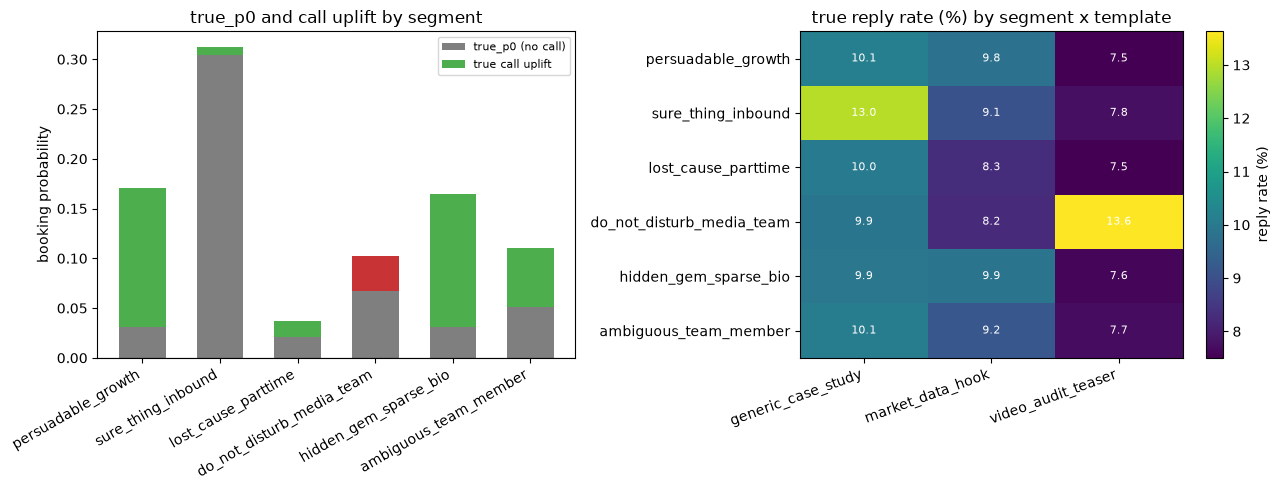

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(SEGMENTS))
width = 0.6
colors_p0 = [PALETTE["p0"]] * len(SEGMENTS)
ax1.bar(x, seg_means["true_p0"], width, label="true_p0 (no call)", color=PALETTE["p0"])
uplift_colors = [PALETTE["uplift_pos"] if v >= 0 else PALETTE["uplift_neg"] for v in seg_means["true_call_uplift"]]
ax1.bar(x, seg_means["true_call_uplift"], width, bottom=seg_means["true_p0"],
        label="true call uplift", color=uplift_colors, alpha=0.85)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(SEGMENTS, rotation=30, ha="right")
ax1.set_ylabel("booking probability")
ax1.set_title("true_p0 and call uplift by segment")
ax1.legend(fontsize=8)

im = ax2.imshow(tmpl_by_seg.values * 100, cmap="viridis", aspect="auto")
ax2.set_xticks(range(3))
ax2.set_xticklabels([TEMPLATE_NAMES[a] for a in TEMPLATE_ORDER], rotation=20, ha="right")
ax2.set_yticks(range(len(SEGMENTS)))
ax2.set_yticklabels(SEGMENTS)
ax2.set_title("true reply rate (%) by segment x template")
for i in range(tmpl_by_seg.shape[0]):
    for j in range(tmpl_by_seg.shape[1]):
        ax2.text(j, i, f"{tmpl_by_seg.values[i, j]*100:.1f}", ha="center", va="center",
                  color="white", fontsize=8)
fig.colorbar(im, ax=ax2, label="reply rate (%)")

fig.tight_layout()
plt.show()


In [6]:
# Pilot construction: (1) which leads are on this month's contact list (a fixed
# selection, not randomized), and (2) the randomization layer on top of it -- who gets
# a setter call (W) and which email template (A) each lead receives. Deterministic
# given seed.

def select_pilot_pool(population: pd.DataFrame, pilot_n: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    positions = rng.choice(len(population), size=pilot_n, replace=False)
    return population.iloc[positions].reset_index(drop=True).copy()


def assign_pilot_treatment(pilot_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(pilot_df)
    out = pilot_df.copy()
    out["W"] = rng.binomial(1, 0.5, size=n)
    out["template"] = rng.integers(0, 3, size=n)
    out["pi_W"] = 0.5            # known propensity of the call (RCT form, Eq. 2.11)
    out["pi_A"] = 1.0 / 3.0      # known propensity of the template draw
    return out


In [7]:
PILOT_N = 3000
LLM_SUBSET_N = 600
NEW_LEADS_N = 400

PILOT_POOL = select_pilot_pool(POPULATION, PILOT_N, seed=SEED + 100)
LLM_SUBSET = PILOT_POOL.iloc[:LLM_SUBSET_N].copy()

print(f"[pilot pool] {len(PILOT_POOL)} leads on this month's contact list; "
      f"LLM smoke-test subset = first {len(LLM_SUBSET)} (already in random order from the draw above)")


[pilot pool] 3000 leads on this month's contact list; LLM smoke-test subset = first 600 (already in random order from the draw above)


## 2. The client's current AI-first outbound system, replicated

The plausible system this section replicates: **(a)** a free, non-LLM `rule_fit_score` (0-100 points from
deals closed, YouTube presence, subscriber count, and inbound lead source -- it never reads the bio);
**(b)** an "AI-first" **LLM lead-fit score** read off each lead's bio text by DeepSeek; **(c)** a policy
where the setter calls the top 20% by fit score, and everyone who gets contacted gets the single template
the team has already decided is "best" (`generic_case_study`).

This is exactly the failure mode RATE warns about. A fit score built from deals/YouTube/subscribers/inbound
status is a **risk score** -- it predicts baseline booking propensity, not causal call uplift -- and the
paper is explicit that this can go wrong: *"A key assumption in order for the RF Risk to achieve a high
RATE is that risk is strongly correlated with the treatment effect"*; when it isn't,
*"the risk-based estimators in consideration would not order patients in accordance with estimated
treatment benefit"* (quoting the SPRINT/ACCORD finding, this notebook's context is realtors not
hypertension). Section 4 shows this concretely with known truth. also applies: a fit
score is not an uplift score, and this notebook does not call it useless unless a proper evaluation (RATE,
in Notebook 3) says so.

**DeepSeek facts** (verified with one live call): endpoint
`https://api.deepseek.com/chat/completions`, model `"deepseek-flash"`; body supports `"temperature"`,
`"thinking": {"type": "disabled"}`, `"response_format": {"type": "json_object"}`; the response has
`choices[0].message.content`, `finish_reason`, and `usage` with `prompt_cache_hit_tokens`,
`prompt_cache_miss_tokens`, `completion_tokens`. The key is read from env `DEEPSEEK_KEY` or a
`DEEPSEEK_KEY=` line in a `.env` walking up from the notebook's cwd, and is **never printed, logged, or
cached**. The client below copies the nlp-job reference notebook's pattern: raw `urllib`, a disk cache keyed
by the sha256 of the request body, `MAX_LIVE_CALLS = 40`, retry on 429/5xx, a session `LLM_STATS` counter,
and a `USAGE_LEDGER` so a fully-cached re-run still reports what the original work cost. Pricing constants
are copied from that reference; **verify them on DeepSeek's pricing page** before relying on them for a real
budget decision.

Before any live call, Section 1's [1.12] self-check verified the bios do not trivially leak `true_segment`
(a held-out bag-of-words classifier stays well under a 0.70 accuracy ceiling) -- spending real money to have
an LLM read bios that were themselves just segment labels in disguise would not test anything. Because live
calls cost real money, this notebook's LLM fit-scoring is a **smoke test, not the full
pipeline**: DeepSeek scores only the first 600 of this month's 3,000-lead pilot pool, in batches of 20
(<=30 live calls), with pydantic-validated JSON output and a fallback to the rule score for any lead whose
response fails schema validation or truncates. Because the fit-score prompt is fixed a priori --
written before any pilot outcome was inspected, describing a generic "who is a good fit for a YouTube growth
service" ICP -- lets it be evaluated on all pilot data it is scored on, without a
train/evaluate split (a *learned*, tuned score would need one). The population-scale "top 20% by fit score"
policy comparison in Section 4 therefore uses the free rule score, not the LLM score, since the LLM budget
only covers 600 of the 3,000 pilot leads -- the LLM score here is evaluated only on its own smoke-test
subset (rank correlations, deciles, AUC), which is this section's own honest scope limit, flagged in the
final report.


In [8]:
# The client's current non-LLM heuristic: a 0-100 point rule score built only from
# structured fields (never reads the bio text). Derived here.

def rule_fit_score(row) -> float:
    pts = 0.0
    pts += min(float(row["deals_last_12m"]), 30.0)                      # up to 30
    pts += 20.0 if bool(row["has_youtube"]) else 0.0                    # up to 20
    pts += min(float(row["yt_subscribers"]) / 1000.0, 30.0)             # up to 30
    pts += 20.0 if row["lead_source"] == "inbound_form" else 0.0        # up to 20
    return float(min(pts, 100.0))


In [9]:
# DeepSeek client: raw urllib, disk-cached by request-body hash, live-call budget,
# and a usage ledger so cached re-runs still report what the work cost. Pattern
# copied from the nlp-job reference notebook's DeepSeek client (its cell 11);
# adapted here with MAX_LIVE_CALLS = 40 (derived here; predeclared) for this
# notebook's smoke test. Never prints, logs, or caches the API key. Audit item 1
# fix: the one-time smoke-test call used to live at the bottom of THIS cell, which
# is tagged "reuse" and gets replayed (by exec() of raw source) in Notebook 3 --
# that would have made a live, uncached, network-touching call on first replay
# there. The smoke test now lives in the next cell, which is NOT tagged "reuse".

DEEPSEEK_URL = "https://api.deepseek.com/chat/completions"
MODEL = "deepseek-flash"
MAX_LIVE_CALLS = 40

_STATS_LOCK = threading.Lock()


class LiveCallBudgetExceeded(RuntimeError):
    pass


class MissingAPIKey(RuntimeError):
    pass


LLM_STATS = {
    "live_calls": 0, "cache_hits": 0, "prompt_cache_hit_tokens": 0,
    "prompt_cache_miss_tokens": 0, "completion_tokens": 0, "http_retries": 0,
    "cached_completion_tokens": 0,  # informational only -- NOT billed
}

# USAGE_LEDGER records the usage of EVERY response this notebook obtains, live or
# cached, tagged by section/kind, so per-section cost tables stay meaningful even
# on a fully-cached re-run (LLM_STATS alone would show ~0 session spend then).
USAGE_LEDGER = []
USED_CACHE_KEYS = set()


def _find_dotenv_key():
    here = NOTEBOOK_DIR
    for d in [here] + list(here.parents):
        candidate = d / ".env"
        if candidate.exists():
            for line in candidate.read_text().splitlines():
                if line.startswith("DEEPSEEK_KEY="):
                    return line.split("=", 1)[1].strip()
    return None


def _get_api_key():
    return os.environ.get("DEEPSEEK_KEY") or _find_dotenv_key()


def _cache_key(body):
    payload = json.dumps(body, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _cache_path(key):
    return CACHE_DIR / key[:2] / f"{key}.json"


def deepseek_chat(body: dict, section: str = "unspecified", kind: str = "batch") -> dict:
    key = _cache_key(body)
    path = _cache_path(key)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            cached = json.load(f)
        resp = cached["response"]
        usage = resp.get("usage", {})
        with _STATS_LOCK:
            LLM_STATS["cache_hits"] += 1
            LLM_STATS["cached_completion_tokens"] += usage.get("completion_tokens", 0)
            USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": True, "usage": usage})
            USED_CACHE_KEYS.add(key)
        return resp

    # Reserve the budget slot ATOMICALLY, under the lock, BEFORE the network call --
    # not after it returns. Audit item 2 fix: the previous version checked
    # LLM_STATS["live_calls"] < MAX_LIVE_CALLS under the lock but only incremented the
    # counter after a successful response, so multiple in-flight ThreadPoolExecutor
    # requests could all pass the check before any of them incremented, letting the
    # true number of concurrent live calls exceed MAX_LIVE_CALLS (predeclared cap,
    # derived here). The slot is released (decremented) below if the call never
    # actually succeeds, so a failed call does not permanently consume budget it
    # never used.
    with _STATS_LOCK:
        if LLM_STATS["live_calls"] >= MAX_LIVE_CALLS:
            raise LiveCallBudgetExceeded(
                f"MAX_LIVE_CALLS ({MAX_LIVE_CALLS}) exceeded -- refusing further live DeepSeek calls."
            )
        LLM_STATS["live_calls"] += 1  # reserved now; released on failure below

    api_key = _get_api_key()
    if api_key is None:
        with _STATS_LOCK:
            LLM_STATS["live_calls"] -= 1  # release: never attempted
        raise MissingAPIKey(
            "DEEPSEEK_KEY not found (checked env var and .env files walking up from cwd) "
            "and this request is a cache miss -- cannot make a live call."
        )

    data = json.dumps(body).encode("utf-8")
    req = urllib.request.Request(
        DEEPSEEK_URL, data=data, method="POST",
        headers={"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"},
    )
    delays = [1, 2, 4, 8]
    last_err = None
    for attempt in range(4):
        try:
            with urllib.request.urlopen(req, timeout=120) as f:
                resp = json.loads(f.read().decode("utf-8"))
            usage = resp.get("usage", {})
            with _STATS_LOCK:
                # NOTE: live_calls was already incremented (reserved) above, before this
                # request was attempted -- do not increment again here (audit item 2 fix).
                LLM_STATS["prompt_cache_hit_tokens"] += usage.get("prompt_cache_hit_tokens", 0)
                LLM_STATS["prompt_cache_miss_tokens"] += usage.get("prompt_cache_miss_tokens", 0)
                LLM_STATS["completion_tokens"] += usage.get("completion_tokens", 0)
                USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": False, "usage": usage})
                USED_CACHE_KEYS.add(key)
            tmp_path = path.with_suffix(f".{threading.get_ident()}.tmp")
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(tmp_path, "w", encoding="utf-8") as f:
                json.dump({"request": body, "response": resp}, f)
            os.replace(tmp_path, path)
            return resp
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            last_err = e
            code_ = getattr(e, "code", None)
            if code_ is not None and code_ != 429 and not (500 <= code_ < 600):
                with _STATS_LOCK:
                    LLM_STATS["live_calls"] -= 1  # release: this call never succeeded
                raise
            with _STATS_LOCK:
                LLM_STATS["http_retries"] += 1
            if attempt < 3:
                time.sleep(delays[attempt])
    with _STATS_LOCK:
        LLM_STATS["live_calls"] -= 1  # release: all retries exhausted, call never succeeded
    raise RuntimeError(f"DeepSeek call failed after 4 attempts: {last_err}")


# Pricing constants copied from the nlp-job reference notebook; verify on DeepSeek's
# pricing page before relying on them for a real budget decision.
def llm_cost_usd(stats: dict, peak: bool = True) -> float:
    if peak:
        in_hit, in_miss, out = 0.006, 0.30, 1.20
    else:
        in_hit, in_miss, out = 0.003, 0.15, 0.60
    return (
        stats["prompt_cache_hit_tokens"] / 1e6 * in_hit
        + stats["prompt_cache_miss_tokens"] / 1e6 * in_miss
        + stats["completion_tokens"] / 1e6 * out
    )


def ledger_cost_usd(entries: list, peak: bool = True) -> float:
    # Cost of the classification WORK represented by `entries`, whether live or
    # cached this session -- unlike LLM_STATS (session spend, ~0 on warm cache).
    if peak:
        in_hit, in_miss, out = 0.006, 0.30, 1.20
    else:
        in_hit, in_miss, out = 0.003, 0.15, 0.60
    total = 0.0
    for e in entries:
        u = e.get("usage", {})
        total += (
            u.get("prompt_cache_hit_tokens", 0) / 1e6 * in_hit
            + u.get("prompt_cache_miss_tokens", 0) / 1e6 * in_miss
            + u.get("completion_tokens", 0) / 1e6 * out
        )
    return total


In [10]:
# Smoke test: one tiny real call (cached from here on, so re-runs make zero live
# calls). Audit item 1 fix: this cell is deliberately NOT tagged "reuse" -- unlike the
# previous version (where this call lived inside the "reuse"-tagged DeepSeek-client
# cell above), Notebook 3 replays every "reuse"-tagged cell's raw source by exec(), so
# a live/network-touching call here must not be reachable just by replaying that cell.
_smoke_body = {
    "model": MODEL,
    "messages": [
        {"role": "system", "content": 'Return json only, exactly: {"ok": true}'},
        {"role": "user", "content": "ping. Return json."},
    ],
    "max_tokens": 50, "temperature": 0,
    "thinking": {"type": "disabled"},
    "response_format": {"type": "json_object"},
}
_smoke_resp = deepseek_chat(_smoke_body, section="setup", kind="smoke_test")
print("smoke test finish_reason:", _smoke_resp["choices"][0]["finish_reason"])
print("smoke test content:", _smoke_resp["choices"][0]["message"]["content"])
print("LLM_STATS:", LLM_STATS)


smoke test finish_reason: stop
smoke test content: {"ok": true}
LLM_STATS: {'live_calls': 0, 'cache_hits': 1, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 5}


In [11]:
# LLM lead-fit score: DeepSeek reads each bio and scores 0-100 fit for a YouTube
# growth service ICP. The ICP prompt is fixed a priori (written before any pilot
# outcome was looked at) -- per , a fixed score may be evaluated
# on all pilot data. Batches of 20 bios; failures fall back to the rule score.

FIT_SYSTEM_PROMPT = '''You are a growth strategist for a YouTube-focused marketing agency \
that helps residential real estate agents ("realtors") get more views, leads, and closed \
deals from video content. Score how good a FIT each realtor is for this service on a 0-100 \
scale, based only on the short bio provided.

Good fit (higher score): an active, established production level; some existing digital \
presence or comfort putting themselves out there (social posting, engaging with clients \
online); room to grow with video specifically (little or no existing YouTube presence, or a \
small/early channel); general signs of ambition or momentum in their business.

Weaker fit (lower score): very low production/part-time with little activity of any kind; \
OR the opposite end -- an established, active YouTube channel already run by a dedicated \
in-house media team, where this service has little left to add.

Judge only what the bio actually states. Do not guess facts it does not mention.

Return json only, exactly this shape: {"results": [{"id": "<id>", "fit": <integer 0-100>, \
"reason": "<=12 words"}]}'''


class FitItem(BaseModel):
    model_config = ConfigDict(extra="forbid")
    id: str
    fit: int
    reason: str


class FitBatchResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    results: list[FitItem]


FIT_FAILURE_COUNTS = Counter()


def _fit_user_message(leads):
    parts = [f"### id={lid}\n{bio}" for lid, bio in leads]
    return "\n\n".join(parts)


def fit_score_batch(leads: list[tuple], section: str = "llm_fit", kind: str = "batch") -> list[dict]:
    # `leads`: list of (lead_id, bio) tuples. One DeepSeek call, <=k items.
    k = len(leads)
    requested_ids = [lid for lid, _ in leads]
    body = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": FIT_SYSTEM_PROMPT},
            {"role": "user", "content": _fit_user_message(leads)},
        ],
        "max_tokens": 40 * k + 200,
        "temperature": 0,
        "thinking": {"type": "disabled"},
        "response_format": {"type": "json_object"},
    }

    def fail_all(status):
        return [{"id": lid, "fit": None, "reason": None, "status": status} for lid in requested_ids]

    # Audit item 3 fix: LiveCallBudgetExceeded/MissingAPIKey used to be re-raised here,
    # which would crash score_leads_fit_llm's ThreadPoolExecutor.map instead of
    # degrading to the documented rule-score fallback (see cell computing n_failed /
    # failure_rate below, and its "failures fall back to the rule score" comment
    # above). Both are now caught and recorded as failed items with a distinct status
    # string, same as any other batch failure.
    try:
        resp = deepseek_chat(body, section=section, kind=kind)
    except LiveCallBudgetExceeded:
        return fail_all("budget_exceeded")
    except MissingAPIKey:
        return fail_all("missing_api_key")
    except Exception:
        return fail_all("http_error")

    choice = resp["choices"][0]
    content = choice["message"]["content"]
    finish_reason = choice["finish_reason"]
    truncated = finish_reason == "length"
    if not content:
        return fail_all("empty_content")
    try:
        raw = json.loads(content)
    except json.JSONDecodeError:
        return fail_all("truncated" if truncated else "json_parse_error")
    try:
        parsed = FitBatchResult.model_validate(raw)
    except ValidationError:
        return fail_all("truncated" if truncated else "schema_violation")

    out, seen = [], set()
    requested_set = set(requested_ids)
    for item in parsed.results:
        if item.id in seen:
            status = "duplicate_id"
        elif item.id not in requested_set:
            status = "unexpected_id"
        elif not (0 <= item.fit <= 100):
            status = "out_of_range"
        else:
            status = "ok"
        seen.add(item.id)
        out.append({"id": item.id, "fit": item.fit, "reason": item.reason, "status": status})
    for lid in requested_ids:
        if lid not in seen:
            out.append({"id": lid, "fit": None, "reason": None,
                        "status": "truncated" if truncated else "missing_id"})
    return out


def score_leads_fit_llm(leads_df: pd.DataFrame, batch_size: int = 20) -> pd.DataFrame:
    # Scores every row of leads_df (id=lead_id, text=bio) via DeepSeek in batches of
    # `batch_size`. Returns a DataFrame indexed like leads_df with llm_fit, llm_reason,
    # llm_status ('ok' or 'failed'), llm_fallback (bool, rule score substituted).
    pairs = list(zip(leads_df["lead_id"], leads_df["bio"]))
    chunks = [pairs[i:i + batch_size] for i in range(0, len(pairs), batch_size)]
    with ThreadPoolExecutor(max_workers=8) as ex:
        batch_lists = list(ex.map(lambda c: fit_score_batch(c, kind=f"k={batch_size}:main"), chunks))
    results = {item["id"]: item for batch in batch_lists for item in batch}

    need_repair = [lid for lid, item in results.items() if item["status"] != "ok"]
    for lid in need_repair:
        FIT_FAILURE_COUNTS[results[lid]["status"]] += 1
    if need_repair:
        by_bio = dict(pairs)
        repair_pairs = [(lid, by_bio[lid]) for lid in need_repair]
        with ThreadPoolExecutor(max_workers=8) as ex:
            repair_lists = list(ex.map(lambda p: fit_score_batch([p], kind=f"k={batch_size}:repair"), repair_pairs))
        for batch in repair_lists:
            for item in batch:
                if item["status"] == "ok":
                    results[item["id"]] = item
                else:
                    FIT_FAILURE_COUNTS[item["status"]] += 1
                    results[item["id"]] = {**item, "status": "failed"}

    rows = []
    for lid in leads_df["lead_id"]:
        item = results[lid]
        ok = item["status"] == "ok"
        rows.append({
            "lead_id": lid,
            "llm_fit_raw": float(item["fit"]) if ok else np.nan,
            "llm_reason": item["reason"] if ok else None,
            "llm_status": "ok" if ok else "failed",
        })
    return pd.DataFrame(rows)


In [12]:
# Run both scores: rule score on the full 3,000-lead pilot pool (free), LLM fit score
# on the 600-lead smoke-test subset only (costs live calls).

PILOT_POOL["rule_fit"] = PILOT_POOL.apply(rule_fit_score, axis=1)
LLM_SUBSET = PILOT_POOL.iloc[:LLM_SUBSET_N].copy()  # refresh: now carries rule_fit too

_calls_before = LLM_STATS["live_calls"]
_llm_scores = score_leads_fit_llm(LLM_SUBSET, batch_size=20)
_calls_used_fit = LLM_STATS["live_calls"] - _calls_before

_llm_scores = _llm_scores.set_index("lead_id")
LLM_SUBSET = LLM_SUBSET.set_index("lead_id")
LLM_SUBSET["llm_status"] = _llm_scores["llm_status"]
LLM_SUBSET["llm_reason"] = _llm_scores["llm_reason"]
LLM_SUBSET["llm_fallback"] = LLM_SUBSET["llm_status"] != "ok"
LLM_SUBSET["llm_fit"] = np.where(
    LLM_SUBSET["llm_fallback"], LLM_SUBSET["rule_fit"], _llm_scores["llm_fit_raw"]
)
LLM_SUBSET = LLM_SUBSET.reset_index()

# Fold the LLM fit score (and fallback flag) back into the 3,000-lead pilot pool;
# leads outside the 600-lead smoke-test subset have llm_fit = NaN (never scored).
PILOT_POOL = PILOT_POOL.merge(
    LLM_SUBSET[["lead_id", "llm_fit", "llm_fallback", "llm_status", "llm_reason"]],
    on="lead_id", how="left",
)

n_failed = int((LLM_SUBSET["llm_status"] == "failed").sum())
failure_rate = n_failed / len(LLM_SUBSET)
rho_llm_rule, _ = spearmanr(LLM_SUBSET["llm_fit"], LLM_SUBSET["rule_fit"])
rho_llm_p0, _ = spearmanr(LLM_SUBSET["llm_fit"], LLM_SUBSET["true_p0"])
rho_llm_uplift, _ = spearmanr(LLM_SUBSET["llm_fit"], LLM_SUBSET["true_call_uplift"])

print(f"[S2.1] live calls used for fit scoring = {_calls_used_fit} "
      f"(threshold <= 30, derived here; predeclared) -> "
      f"{'PASS' if _calls_used_fit <= 30 else 'FAIL'}")
print(f"[S2.2] total live calls this session = {LLM_STATS['live_calls']} (cap MAX_LIVE_CALLS={MAX_LIVE_CALLS}) -> "
      f"{'PASS' if LLM_STATS['live_calls'] <= MAX_LIVE_CALLS else 'FAIL'}")
print(f"[S2.3] LLM scoring failure rate = {failure_rate*100:.1f}% ({n_failed}/{len(LLM_SUBSET)}), "
      f"threshold < 20% (derived here; predeclared) -> "
      f"{'PASS' if failure_rate < 0.20 else 'FAIL'}; failures: {dict(FIT_FAILURE_COUNTS)}")
print(f"[S2.4] Spearman(LLM fit, rule fit) = {rho_llm_rule:.3f}, threshold > 0 -> "
      f"{'PASS' if rho_llm_rule > 0 else 'FAIL'}")
print(f"[S2.5] Spearman(LLM fit, true p0) = {rho_llm_p0:.3f} vs Spearman(LLM fit, true call uplift) = "
      f"{rho_llm_uplift:.3f}. Predicted (RATE's risk-vs-benefit point): |rho_p0| > |rho_uplift| -> "
      f"{'PASS' if abs(rho_llm_p0) > abs(rho_llm_uplift) else 'FAIL (reporting as-is, not adjusted)'}")

# Definition-hard segments: does the LLM fit score actually get fooled?
seg_fit_means = LLM_SUBSET.groupby("true_segment")["llm_fit"].mean()
print("\n[S2.6] mean LLM fit score by true segment (definition-hard check, informational):")
print(seg_fit_means.round(1).to_string())
pg = seg_fit_means.get("persuadable_growth", float("nan"))
hg = seg_fit_means.get("hidden_gem_sparse_bio", float("nan"))
pg_up, hg_up = SEG_UPLIFT["persuadable_growth"] * 100, SEG_UPLIFT["hidden_gem_sparse_bio"] * 100
print(f"      persuadable_growth (LLM fit {pg:.1f}, true mean uplift {pg_up:.0f}pp) vs "
      f"hidden_gem_sparse_bio (LLM fit {hg:.1f}, true mean uplift {hg_up:.0f}pp) -- similar true "
      f"upside, and any LLM-fit gap between them shows the low-cue-frequency bio is costing "
      f"hidden_gem leads real fit score.")

# Ledger cost of the 600-lead fit-scoring work THIS RUN represents (must stay non-zero
# even on a fully-cached re-run, since it reflects what the work cost when the tokens
# were originally produced, not this session's live spend).
LEDGER_COST_PEAK_PER_1K = ledger_cost_usd(USAGE_LEDGER, peak=True) / len(LLM_SUBSET) * 1000
LEDGER_COST_OFFPEAK_PER_1K = ledger_cost_usd(USAGE_LEDGER, peak=False) / len(LLM_SUBSET) * 1000
print(f"[S2.7] ledger cost of this section's LLM fit-scoring work, peak pricing = "
      f"${LEDGER_COST_PEAK_PER_1K:.4f}/1,000 leads, threshold > $0 (non-zero even from cache) -> "
      f"{'PASS' if LEDGER_COST_PEAK_PER_1K > 0 else 'FAIL'}")


[S2.1] live calls used for fit scoring = 0 (threshold <= 30, derived here; predeclared) -> PASS
[S2.2] total live calls this session = 0 (cap MAX_LIVE_CALLS=40) -> PASS
[S2.3] LLM scoring failure rate = 0.0% (0/600), threshold < 20% (derived here; predeclared) -> PASS; failures: {}
[S2.4] Spearman(LLM fit, rule fit) = 0.248, threshold > 0 -> PASS
[S2.5] Spearman(LLM fit, true p0) = 0.106 vs Spearman(LLM fit, true call uplift) = 0.184. Predicted (RATE's risk-vs-benefit point): |rho_p0| > |rho_uplift| -> FAIL (reporting as-is, not adjusted)

[S2.6] mean LLM fit score by true segment (definition-hard check, informational):
true_segment
ambiguous_team_member        53.9
do_not_disturb_media_team    50.9
hidden_gem_sparse_bio        57.0
lost_cause_parttime          41.0
persuadable_growth           60.8
sure_thing_inbound           62.9
      persuadable_growth (LLM fit 60.8, true mean uplift 14pp) vs hidden_gem_sparse_bio (LLM fit 57.0, true mean uplift 13pp) -- similar true upside, and a

#### How to read this chart

**Left two panels:** each point is one of the 600 LLM-smoke-test leads, colored by true segment. Left-middle
panel plots LLM fit score against `true_p0` (baseline booking odds); left-right panel plots it against
`true_call_uplift`. If the LLM fit score is really tracking *booking propensity* rather than *causal call
benefit* -- the risk-vs-uplift distinction RATE warns about -- the left panel should show a visibly
tighter, more positive relationship than the right panel, and `sure_thing_inbound` (high `true_p0`, near-zero
uplift) should score high on the left but not stand out on the right. For the realtor-outreach job, this is
the diagnostic that tells the client whether their "AI-first" score is actually finding upside, or just
finding people who were going to book anyway.

**Right panel:** the cost of this smoke test's own scoring work, in USD per 1,000 leads scored, at peak vs.
off-peak DeepSeek pricing (both pricing tables copied from the nlp-job reference; verify before using for a
real budget). This is the number a human would extrapolate to decide whether scoring the full pilot (or
every new lead) by LLM is affordable, versus staying with the free rule score.


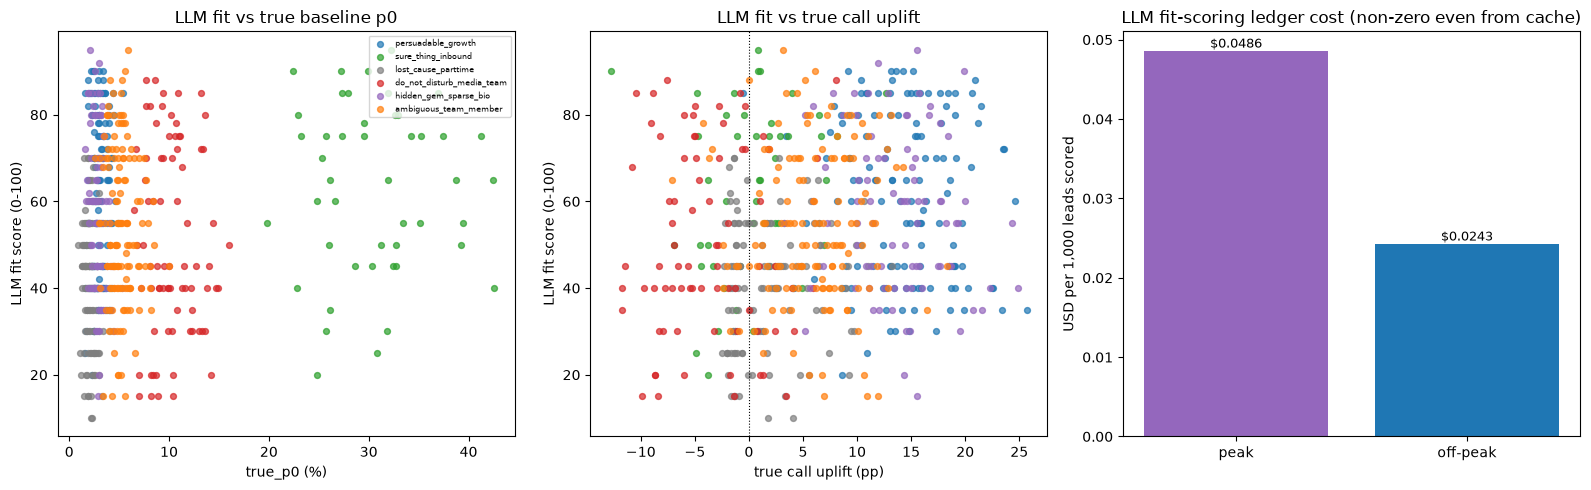

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

for seg in SEGMENTS:
    sub = LLM_SUBSET[LLM_SUBSET["true_segment"] == seg]
    ax1.scatter(sub["true_p0"] * 100, sub["llm_fit"], s=18, alpha=0.7, color=PALETTE[seg], label=seg)
ax1.set_xlabel("true_p0 (%)")
ax1.set_ylabel("LLM fit score (0-100)")
ax1.set_title("LLM fit vs true baseline p0")
ax1.legend(fontsize=6, loc="upper right")

for seg in SEGMENTS:
    sub = LLM_SUBSET[LLM_SUBSET["true_segment"] == seg]
    ax2.scatter(sub["true_call_uplift"] * 100, sub["llm_fit"], s=18, alpha=0.7, color=PALETTE[seg], label=seg)
ax2.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax2.set_xlabel("true call uplift (pp)")
ax2.set_ylabel("LLM fit score (0-100)")
ax2.set_title("LLM fit vs true call uplift")

bars = ax3.bar(["peak", "off-peak"], [LEDGER_COST_PEAK_PER_1K, LEDGER_COST_OFFPEAK_PER_1K],
                color=[PALETTE["llm_score"], PALETTE["rule_score"]])
ax3.set_ylabel("USD per 1,000 leads scored")
ax3.set_title("LLM fit-scoring ledger cost (non-zero even from cache)")
for b, v in zip(bars, [LEDGER_COST_PEAK_PER_1K, LEDGER_COST_OFFPEAK_PER_1K]):
    ax3.text(b.get_x() + b.get_width() / 2, v, f"${v:.4f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()


## 3. The randomized pilot the analysis rests on

This month's 3,000-lead pilot pool (Section 2's fixed contact list) gets a randomization layer on top:
setter call `W ~ Bernoulli(0.5)` and email template `A ~ Uniform{0,1,2}`, drawn **independently**, with
propensities `pi_W = 0.5` and `pi_A = 1/3` recorded on every row. `booked_call` and `positive_reply` are then
drawn from the potential-outcome model built in Section 1, realized according to whichever `(W, A)` each
lead actually received.

Randomization is exactly what later lets Notebook 3 use RATE and KPT off the shelf. RATE's estimator for a
randomized trial plugs the *known* propensity directly into the AIPW score: *"Randomized Controlled Trials
(Equation 2.11): Gamma_hat_i = m_hat(X_i,1) - m_hat(X_i,0) + (W_i - pi)/(pi(1-pi)) * (Y_i - m_hat(X_i,W_i))"*. KPT's Assumption 3 (strong overlap) is satisfied by construction here since `pi_A = 1/3` for every
lead and every arm: *"(Strong overlap) There exists 0 < eta < 1 such that for each a and each x,
p(a|x) in [eta, 1-eta]"*. If the human running this project instead has **historical, non-randomized**
outreach data, both papers still apply, but need the harder assumption: unconfoundedness plus an
*estimated* propensity, `e_hat(x)`, in place of the known `pi` -- RATE's observational form is
*"Observational Studies under Unconfoundedness (Equation 2.12): Gamma_hat_i = m_hat(X_i,1) - m_hat(X_i,0) +
(W_i - e_hat(X_i))/(e_hat(X_i)(1-e_hat(X_i))) * (Y_i - m_hat(X_i,W_i))"* -- and KPT's Assumption 2
(unconfoundedness, `Y_i perp A_i | X_i`) plus a consistently estimated propensity model in place of the
known design probability. Balance checks below confirm the randomization behaved as designed; a fresh
400-lead `new_leads` batch (same generator, uncontacted) is also created here for Notebook 3's LLM pretest,
and both are saved to CSV.


In [14]:
# Reply/booking outcome model: draws REALIZED binary outcomes from the potential-
# outcome probabilities already stored on each row, given an assignment (W, template).
# Deterministic given seed. This is what turns "latent truth" into what the pilot
# actually observes.

def draw_realized_outcomes(df: pd.DataFrame, W: np.ndarray, template: np.ndarray, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(df)
    p_call = np.where(W == 1, df["true_p1"].to_numpy(), df["true_p0"].to_numpy())
    booked_call = (rng.random(n) < p_call).astype(int)

    reply_p_matrix = np.stack([df[f"true_reply_p_tmpl{a}"].to_numpy() for a in TEMPLATE_ORDER], axis=1)
    p_reply = reply_p_matrix[np.arange(n), template]
    positive_reply = (rng.random(n) < p_reply).astype(int)
    return pd.DataFrame({"booked_call": booked_call, "positive_reply": positive_reply})


In [15]:
PILOT_POOL = assign_pilot_treatment(PILOT_POOL, seed=SEED + 200)
n_pilot = len(PILOT_POOL)
W = PILOT_POOL["W"].to_numpy()
template = PILOT_POOL["template"].to_numpy()

realized = draw_realized_outcomes(PILOT_POOL, W, template, seed=SEED + 201)
PILOT_POOL["booked_call"] = realized["booked_call"]
PILOT_POOL["positive_reply"] = realized["positive_reply"]

NEW_LEADS = generate_leads(NEW_LEADS_N, seed=SEED + 900)

print(f"[3.1] pilot pool n={n_pilot}, W~Bernoulli(0.5), template~Uniform{{0,1,2}}, independent, "
      "propensities recorded (pi_W, pi_A)")

# balance check: standardized mean difference of W and template shares across segments
def std_mean_diff(x1, x0):
    p1, p0 = x1.mean(), x0.mean()
    v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    denom = math.sqrt((v1 + v0) / 2)
    return 0.0 if denom == 0 else abs(p1 - p0) / denom

max_smd_w = 0.0
for seg in SEGMENTS:
    in_seg = (PILOT_POOL["true_segment"] == seg).to_numpy()
    smd = std_mean_diff(in_seg[W == 1].astype(float), in_seg[W == 0].astype(float))
    max_smd_w = max(max_smd_w, smd)
print(f"[3.2] max |standardized mean diff| of segment share across W=1 vs W=0 = {max_smd_w:.3f}, "
      f"threshold < 0.1 (derived here; predeclared) -> {'PASS' if max_smd_w < 0.1 else 'FAIL'}")

max_smd_a = 0.0
for seg in SEGMENTS:
    in_seg = (PILOT_POOL["true_segment"] == seg).to_numpy()
    for a in TEMPLATE_ORDER:
        smd = std_mean_diff(in_seg[template == a].astype(float), in_seg[template != a].astype(float))
        max_smd_a = max(max_smd_a, smd)
print(f"[3.3] max |standardized mean diff| of segment share across any template arm vs rest = {max_smd_a:.3f}, "
      f"threshold < 0.1 (derived here; predeclared) -> {'PASS' if max_smd_a < 0.1 else 'FAIL'}")

k_called = int((PILOT_POOL["W"] == 1).sum())
print(f"[3.4] share called (W=1) = {fmt_ci(*wilson_ci(k_called, n_pilot))}, target ~50% -> "
      f"{'PASS' if 0.45 <= k_called/n_pilot <= 0.55 else 'FAIL'}")

booked_uncalled = PILOT_POOL.loc[PILOT_POOL["W"] == 0, "booked_call"]
booked_called = PILOT_POOL.loc[PILOT_POOL["W"] == 1, "booked_call"]
# Stored (not just printed) so the pilot-outcomes chart cell below can plot these
# exact intervals rather than recomputing wilson_ci itself (audit item 6 fix).
booked_ci_w0 = wilson_ci(booked_uncalled.sum(), len(booked_uncalled))
booked_ci_w1 = wilson_ci(booked_called.sum(), len(booked_called))
print(f"[3.5] realized booked rate, uncalled = {fmt_ci(*booked_ci_w0)}")
print(f"[3.6] realized booked rate, called   = {fmt_ci(*booked_ci_w1)}")

reply_rates = PILOT_POOL.groupby("template")["positive_reply"].agg(["sum", "count"])
tmpl_ci = {}  # stored for the pilot-outcomes chart cell below (audit item 6 fix)
for a in TEMPLATE_ORDER:
    s, c = reply_rates.loc[a, "sum"], reply_rates.loc[a, "count"]
    tmpl_ci[a] = wilson_ci(s, c)
    print(f"[3.7.{TEMPLATE_NAMES[a]}] realized reply rate = {fmt_ci(*tmpl_ci[a])}")

print(f"[3.8] new_leads for NB3's LLM pretest: n={len(NEW_LEADS)} (fresh draw, no pilot contact yet)")

# --- save CSVs for NB3 ---
PILOT_POOL.to_csv(DATA_DIR / "pilot_leads.csv", index=False)
NEW_LEADS.to_csv(DATA_DIR / "new_leads.csv", index=False)
print(f"[3.9] saved data/pilot_leads.csv ({PILOT_POOL.shape[0]} rows, {PILOT_POOL.shape[1]} cols) "
      f"and data/new_leads.csv ({NEW_LEADS.shape[0]} rows, {NEW_LEADS.shape[1]} cols)")


[3.1] pilot pool n=3000, W~Bernoulli(0.5), template~Uniform{0,1,2}, independent, propensities recorded (pi_W, pi_A)
[3.2] max |standardized mean diff| of segment share across W=1 vs W=0 = 0.042, threshold < 0.1 (derived here; predeclared) -> PASS
[3.3] max |standardized mean diff| of segment share across any template arm vs rest = 0.077, threshold < 0.1 (derived here; predeclared) -> PASS
[3.4] share called (W=1) = 49.00% (95% CI [47.21%, 50.79%]), target ~50% -> PASS
[3.5] realized booked rate, uncalled = 6.21% (95% CI [5.11%, 7.53%])
[3.6] realized booked rate, called   = 11.09% (95% CI [9.58%, 12.80%])
[3.7.generic_case_study] realized reply rate = 9.45% (95% CI [7.81%, 11.40%])
[3.7.market_data_hook] realized reply rate = 9.40% (95% CI [7.72%, 11.40%])
[3.7.video_audit_teaser] realized reply rate = 8.65% (95% CI [7.06%, 10.55%])
[3.8] new_leads for NB3's LLM pretest: n=400 (fresh draw, no pilot contact yet)
[3.9] saved data/pilot_leads.csv (3000 rows, 31 cols) and data/new_leads.cs

#### How to read this chart

**Left:** realized `booked_call` rate for uncalled vs. called leads in the 3,000-lead pilot, with Wilson 95%
intervals. This is the raw randomized comparison Notebook 3's RATE analysis will slice by score; here it
should land close to the population targets from Section 1 (~6% uncalled, ~11-13% called), confirming the
pilot draw behaved like the generator's design, not a fluke of one sample.

**Right:** realized `positive_reply` rate by email template, with Wilson 95% intervals, across all 3,000
randomized template assignments -- the raw input to Notebook 3's template-personalization test. For the
realtor-outreach job, this is the number the client's team would currently look at to justify "we already
picked the best template" -- Section 1 showed there's a real but modest population-level personalization
gain (`psi`) hiding underneath this population-average view; Notebook 3 tests whether the pilot has the
power to detect it.


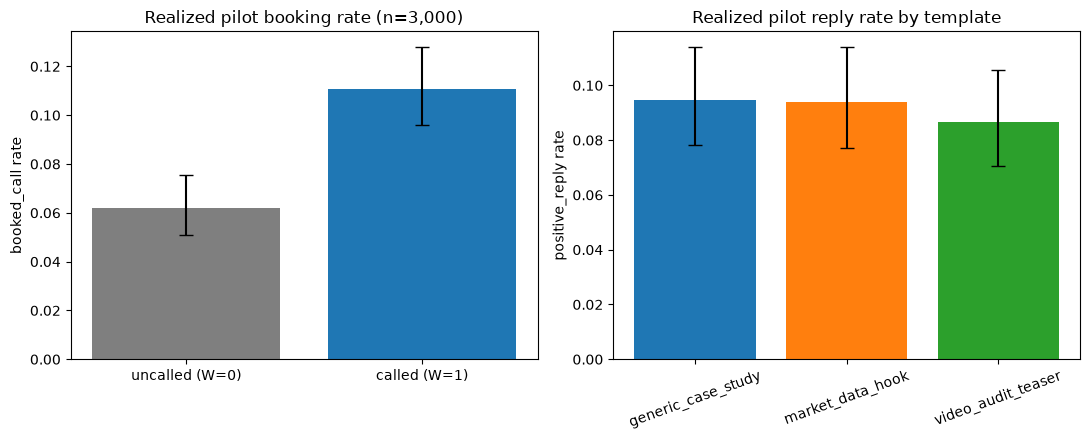

In [16]:
# Audit item 6 fix: this cell used to call wilson_ci(...) itself (interval
# computation inline in a plot-only cell). It now only plots booked_ci_w0/w1 and
# tmpl_ci, both precomputed in the balance-check cell above.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

groups = ["uncalled (W=0)", "called (W=1)"]
means, los, his = [], [], []
for lo, mid, hi in (booked_ci_w0, booked_ci_w1):
    means.append(mid); los.append(mid - lo); his.append(hi - mid)
ax1.bar(groups, means, yerr=[los, his], capsize=5, color=[PALETTE["not_called"], PALETTE["called"]])
ax1.set_ylabel("booked_call rate")
ax1.set_title("Realized pilot booking rate (n=3,000)")

tmpl_means, tmpl_lo, tmpl_hi = [], [], []
for a in TEMPLATE_ORDER:
    lo, mid, hi = tmpl_ci[a]
    tmpl_means.append(mid); tmpl_lo.append(mid - lo); tmpl_hi.append(hi - mid)
ax2.bar([TEMPLATE_NAMES[a] for a in TEMPLATE_ORDER], tmpl_means, yerr=[tmpl_lo, tmpl_hi], capsize=5,
        color=[PALETTE[f"tmpl{a}_{TEMPLATE_NAMES[a]}"] for a in TEMPLATE_ORDER])
ax2.set_ylabel("positive_reply rate")
ax2.set_title("Realized pilot reply rate by template")
ax2.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()


## 4. Baseline audit the client would run today

**What a dashboard shows today**, using only the 600-lead LLM smoke-test subset and the realized pilot
outcomes: the fit score looks great at predicting `booked_call` (a naive AUC, and a rising booked-rate curve
by fit decile among called leads), and "we called the top 20% by fit score and they booked at a much higher
rate than everyone else" reads as a targeting win.

**The honest version**, using the latent truth this notebook controls: computing the *true average call
uplift* actually captured inside the top-20%-by-fit-score group versus the top-20%-by-true-uplift group
(the unattainable oracle) versus a random 20%, at population scale, shows a real gap -- the fit score
predicts who *books*, which (per Section 2) correlates more with baseline propensity than with the
incremental value of a call. This is precisely RATE's point: *"the risk-based estimators in consideration
would not order patients in accordance with estimated treatment benefit"* when risk and effect aren't
correlated -- and it echoes what the Criteo marketing application found: *"The average treatment effect
among the highest prioritized individuals according to the CATE-based rule is much higher than for the
baseline-based rule at similar fractions treated. However, the difference disappears once the fraction
treated is more than 10%"* -- the gain from a *causal* score over a *risk* score concentrates in a thin
top slice, not spread evenly across a 20% capacity cutoff.

The empirical (not oracle) version -- a pilot difference-in-means call effect by rule-fit quintile, with
Newcombe intervals for the difference of two proportions -- is shown last, and deliberately **not** dressed
up as more certain than it is: each quintile x arm cell has only a few hundred pilot leads, several
intervals will be wide enough to include zero, and that is reported as "not significant at this n," not
silently upgraded to a PASS.


In [17]:
# (a) What a dashboard shows today, using the 600-lead LLM smoke-test subset. Refresh
# LLM_SUBSET from PILOT_POOL so it carries the Section 3 randomization/outcome columns
# (W, template, booked_call, positive_reply) on top of Section 2's llm_fit/rule_fit.
LLM_SUBSET = PILOT_POOL[PILOT_POOL["llm_fit"].notna()].copy()

auc_llm = roc_auc_score(LLM_SUBSET["booked_call"], LLM_SUBSET["llm_fit"])
print(f"[4.1] naive AUC of LLM fit score for booked_call (n={len(LLM_SUBSET)}, conflates W) = {auc_llm:.3f}, "
      f"threshold > 0.5 -> {'PASS' if auc_llm > 0.5 else 'FAIL'}")

LLM_SUBSET["fit_decile"] = pd.qcut(LLM_SUBSET["llm_fit"], 10, labels=False, duplicates="drop")
called_sub = LLM_SUBSET[LLM_SUBSET["W"] == 1]
decile_rates = called_sub.groupby("fit_decile")["booked_call"].mean()
rho_decile, _ = spearmanr(decile_rates.index, decile_rates.values)

# Audit item 5 fix: this small-n check (~31 leads/decile) used to print a bare
# PASS/FAIL despite this same cell warning elsewhere to "read directionally" --
# inconsistent with that caveat. A bootstrap 95% CI on the rank correlation itself
# now backs whatever label is printed (bootstrap resample count is derived here;
# predeclared), instead of a threshold crossing alone.
_boot_rng = np.random.default_rng(SEED + 400)
_n_boot = 2000
_called_idx = called_sub.index.to_numpy()
_boot_rhos = []
for _ in range(_n_boot):
    _samp_idx = _boot_rng.choice(_called_idx, size=len(_called_idx), replace=True)
    _samp_rates = called_sub.loc[_samp_idx].groupby("fit_decile")["booked_call"].mean()
    if _samp_rates.index.nunique() < 3:
        continue  # degenerate resample (too few distinct deciles present), skip
    _r, _ = spearmanr(_samp_rates.index, _samp_rates.values)
    if not np.isnan(_r):
        _boot_rhos.append(_r)
_rho_lo, _rho_hi = np.percentile(_boot_rhos, [2.5, 97.5])
print(f"[4.2] booked rate by LLM-fit decile among CALLED leads (n={len(called_sub)}, "
      f"~{len(called_sub)//decile_rates.index.nunique()} per decile -- small n, read directionally):")
print(decile_rates.round(3).to_string())
print(f"      Spearman(decile rank, booked rate) = {rho_decile:.3f}, bootstrap 95% CI "
      f"[{_rho_lo:.3f}, {_rho_hi:.3f}] (n_boot={_n_boot}, {len(_boot_rhos)} valid resamples) -> "
      f"{'positive, CI excludes 0' if _rho_lo > 0 else ('negative, CI excludes 0' if _rho_hi < 0 else 'CI includes 0 -- not significant at this n')}")

top20_llm = LLM_SUBSET.nlargest(int(0.20 * len(LLM_SUBSET)), "llm_fit")
bottom80_llm = LLM_SUBSET.drop(top20_llm.index)
top20_called = top20_llm[top20_llm["W"] == 1]
bottom80_called = bottom80_llm[bottom80_llm["W"] == 1]
# Audit item 5 fix: this used to compare top20_called against "overall_called",
# which INCLUDES top20_called inside it (not an independent comparison group), then
# printed a bare PASS/FAIL. Now compares top-20% (called) against the other 80%
# (called) -- two independent groups -- with a Newcombe CI on the difference,
# consistent with how [4.6] below reports the pilot quintile comparisons.
lo43, diff43, hi43 = newcombe_diff_ci(
    top20_called["booked_call"].sum(), len(top20_called),
    bottom80_called["booked_call"].sum(), len(bottom80_called),
)
sig43 = "excludes 0 (significant at this n)" if (lo43 > 0 or hi43 < 0) else "includes 0 -- NOT significant at this n"
print(f"[4.3] naive dashboard line: 'top-20% by fit score, called, booked "
      f"{top20_called['booked_call'].mean()*100:.1f}% vs {bottom80_called['booked_call'].mean()*100:.1f}% "
      f"for the other 80% (both among called)' -> looks like a targeting win. "
      f"diff={diff43*100:+.1f}pp, 95% CI [{lo43*100:+.1f}, {hi43*100:+.1f}]pp -> {sig43}")

# (b) Honest version: population-scale true uplift captured at 20% capacity, three rules.
# Rule score is used at population scale (free); LLM fit score is only affordable at the
# 600-lead smoke-test scale (see Section 2), so it is not part of this population-scale panel.
POPULATION["rule_fit"] = POPULATION.apply(rule_fit_score, axis=1)
cap = int(0.20 * len(POPULATION))
top20_rule = POPULATION.nlargest(cap, "rule_fit")["true_call_uplift"]
top20_oracle = POPULATION.nlargest(cap, "true_call_uplift")["true_call_uplift"]
rand_rng = np.random.default_rng(SEED + 300)
rand20_idx = rand_rng.choice(len(POPULATION), size=cap, replace=False)
top20_random = POPULATION.iloc[rand20_idx]["true_call_uplift"]

lo_r, mid_r, hi_r = mean_ci(top20_rule)
lo_o, mid_o, hi_o = mean_ci(top20_oracle)
lo_x, mid_x, hi_x = mean_ci(top20_random)
print(f"[4.4] true avg call uplift captured at 20% capacity (n={cap} each, population-scale, derived here):")
print(f"      rule-fit top20%  = {fmt_ci(lo_r, mid_r, hi_r)}")
print(f"      oracle top20%    = {fmt_ci(lo_o, mid_o, hi_o)}  (true_call_uplift itself -- upper bound)")
print(f"      random 20%       = {fmt_ci(lo_x, mid_x, hi_x)}")
ordering_ok = mid_o >= mid_r >= mid_x - 1e-9
print(f"      expected ordering oracle >= rule >= random -> {'PASS' if ordering_ok else 'FAIL'}")
if not ordering_ok:
    print("      NOTE: rule-fit top20% < random 20% here -- rule_fit_score's heaviest weights "
          "(has_youtube, subscribers, inbound) point straight at do_not_disturb_media_team and "
          "sure_thing_inbound, the two lowest/negative-uplift segments. Rule-based targeting is "
          "worse than not targeting at all on this population, an even sharper version of RATE's "
          "risk-is-not-benefit point than 'merely no better than random'.")

money_left_pp = (mid_o - mid_r) * 100
print(f"[4.5] 'money left on table': oracle - rule-fit top20% uplift = {money_left_pp:.2f}pp, "
      f"threshold > 0 -> {'PASS' if money_left_pp > 0 else 'FAIL'} "
      f"(relative-% framing is skipped here since the rule-fit baseline is negative, not just smaller)")

# (c) Empirical difference-in-means call effect by rule_fit quintile, from the PILOT (n=3000).
PILOT_POOL["fit_quintile"] = pd.qcut(PILOT_POOL["rule_fit"], 5, labels=False, duplicates="drop")
print(f"[4.6] empirical call effect by rule_fit quintile, PILOT n={len(PILOT_POOL)} "
      f"(~{len(PILOT_POOL)//5} per quintile, further split by W -- n per cell is small, "
      "read the intervals, not just the point estimate):")
for q in sorted(PILOT_POOL["fit_quintile"].dropna().unique()):
    sub = PILOT_POOL[PILOT_POOL["fit_quintile"] == q]
    called = sub[sub["W"] == 1]["booked_call"]
    uncalled = sub[sub["W"] == 0]["booked_call"]
    lo, diff, hi = newcombe_diff_ci(called.sum(), len(called), uncalled.sum(), len(uncalled))
    sig = "excludes 0 (significant at this n)" if (lo > 0 or hi < 0) else "includes 0 -- NOT significant at this n"
    print(f"      quintile {int(q)}: n_called={len(called)}, n_uncalled={len(uncalled)}, "
          f"diff={diff*100:+.1f}pp, 95% CI [{lo*100:+.1f}, {hi*100:+.1f}]pp -> {sig}")

# Precomputed per-decile Wilson CIs for the dashboard chart cell below (audit item 6
# fix -- this used to be computed inline inside that plot-only cell).
decile_list = sorted(LLM_SUBSET["fit_decile"].dropna().unique())
decile_called_ci, decile_notcalled_ci = {}, {}
for _d in decile_list:
    _sub = LLM_SUBSET[LLM_SUBSET["fit_decile"] == _d]
    _c = _sub[_sub["W"] == 1]["booked_call"]
    _u = _sub[_sub["W"] == 0]["booked_call"]
    decile_called_ci[_d] = wilson_ci(_c.sum(), len(_c))
    decile_notcalled_ci[_d] = wilson_ci(_u.sum(), len(_u))
print(f"\n[4.7] per-decile Wilson CIs computed for {len(decile_list)} LLM-fit deciles "
      "(called vs. not-called), for the dashboard chart below -- informational, same "
      "small-n caveat as [4.2].")


[4.1] naive AUC of LLM fit score for booked_call (n=600, conflates W) = 0.582, threshold > 0.5 -> PASS


[4.2] booked rate by LLM-fit decile among CALLED leads (n=283, ~31 per decile -- small n, read directionally):
fit_decile
0    0.114
1    0.066
2    0.079
3    0.125
4    0.087
5    0.103
6    0.111
7    0.143
8    0.231
      Spearman(decile rank, booked rate) = 0.600, bootstrap 95% CI [-0.184, 0.833] (n_boot=2000, 2000 valid resamples) -> CI includes 0 -- not significant at this n
[4.3] naive dashboard line: 'top-20% by fit score, called, booked 18.2% vs 9.2% for the other 80% (both among called)' -> looks like a targeting win. diff=+9.0pp, 95% CI [-0.2, +21.5]pp -> includes 0 -- NOT significant at this n
[4.4] true avg call uplift captured at 20% capacity (n=1200 each, population-scale, derived here):
      rule-fit top20%  = -1.86% (95% CI [-2.15%, -1.57%])
      oracle top20%    = 17.08% (95% CI [16.93%, 17.24%])  (true_call_uplift itself -- upper bound)
      random 20%       = 6.32% (95% CI [5.88%, 6.76%])
      expected ordering oracle >= rule >= random -> FAIL
      NOTE: rule

#### How to read this chart

**Left:** booked_call rate by LLM-fit decile (600-lead subset), split into called (blue) vs. not-called
(grey), with Wilson 95% intervals. The dashboard story is "higher decile books more" -- watch whether that
rises for *both* colors together (a sign the score is finding higher-baseline leads, not higher-uplift
ones) or mainly for the called line (which would actually support the score). Each decile here is only
~30-60 leads, so the intervals are wide; don't over-read a single decile's wiggle.

**Right:** true average call uplift *actually captured* at a fixed 20% capacity, for three ways of picking
that 20% -- the free rule score (what the client can afford at population scale today), the unattainable
oracle (top 20% by `true_call_uplift` itself), and a random 20% as the no-targeting floor. The gap between
the oracle bar and the rule-score bar is the "money left on the table" number Section 2/4's markdown argued
for. On this population the rule-score bar is not just smaller than the oracle bar -- it is **negative**
(-1.86%, 95% CI [-2.15%, -1.57%] at [4.4]) and sits well *below* the random-targeting floor (6.32%, 95% CI
[5.88%, 6.76%]), not above it (audit item 4 fix -- this used to say the rule score "clears the
random-targeting floor by a wide margin," backwards from [4.4]'s own numbers). The honest client-facing
line here is sharper than "captures only part of the achievable uplift": at this 20% capacity, this
risk-flavored score doesn't just fail to find the best 20% of leads -- calling its top 20% performs *worse*
than calling a random 20%, per [4.4]'s note.


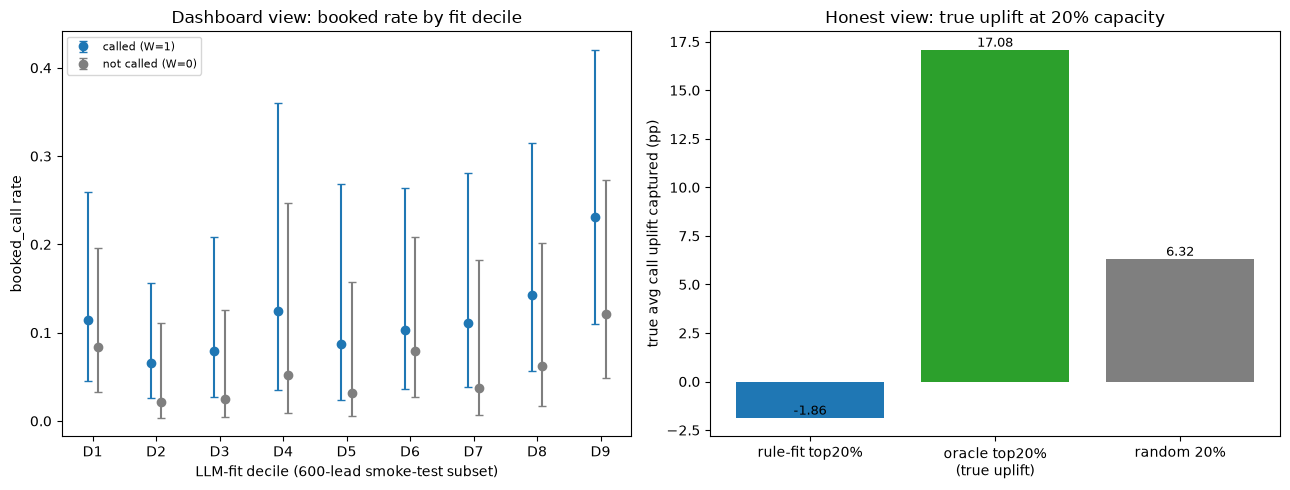

In [18]:
# Audit item 6 fix: this cell used to call wilson_ci(...) itself per decile (interval
# computation inline in a plot-only cell). It now only plots decile_list /
# decile_called_ci / decile_notcalled_ci, all precomputed in the Section 4
# computation cell above ([4.7]).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

deciles = decile_list
called_means, called_lo, called_hi = [], [], []
notcalled_means, notcalled_lo, notcalled_hi = [], [], []
for d in deciles:
    lo, mid, hi = decile_called_ci[d]
    called_means.append(mid); called_lo.append(mid - lo); called_hi.append(hi - mid)
    lo, mid, hi = decile_notcalled_ci[d]
    notcalled_means.append(mid); notcalled_lo.append(mid - lo); notcalled_hi.append(hi - mid)

x = np.arange(len(deciles))
ax1.errorbar(x - 0.08, called_means, yerr=[called_lo, called_hi], fmt="o", color=PALETTE["called"],
             label="called (W=1)", capsize=3)
ax1.errorbar(x + 0.08, notcalled_means, yerr=[notcalled_lo, notcalled_hi], fmt="o", color=PALETTE["not_called"],
             label="not called (W=0)", capsize=3)
ax1.set_xticks(x)
ax1.set_xticklabels([f"D{int(d)+1}" for d in deciles])
ax1.set_xlabel("LLM-fit decile (600-lead smoke-test subset)")
ax1.set_ylabel("booked_call rate")
ax1.set_title("Dashboard view: booked rate by fit decile")
ax1.legend(fontsize=8)

labels = ["rule-fit top20%", "oracle top20%\n(true uplift)", "random 20%"]
means = [mid_r, mid_o, mid_x]  # computed in the Section 4 computation cell above
colors = [PALETTE["true_uplift_rule"], PALETTE["true_uplift_oracle"], PALETTE["true_uplift_random"]]
bars = ax2.bar(labels, [m * 100 for m in means], color=colors)
ax2.set_ylabel("true avg call uplift captured (pp)")
ax2.set_title("Honest view: true uplift at 20% capacity")
for b, m in zip(bars, means):
    ax2.text(b.get_x() + b.get_width() / 2, m * 100, f"{m*100:.2f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()


## 5. Results summary and what exists now vs. what Notebook 3 adds

**What this notebook built, with known latent truth:**

| Piece | What it is | Where |
|---|---|---|
| `generate_leads(n, seed)` | ~6,000-lead synthetic population, 6 latent segments, potential outcomes for `booked_call` (call) and `positive_reply` (3 email templates) | Section 1 |
| `true_call_uplift`, `psi` | population-level truth: real call ATE, real (small, positive) template-personalization gain over a depth-<=2 policy class | Section 1 |
| `rule_fit_score` | free, non-LLM 0-100 heuristic (deals, YouTube, subscribers, inbound) | Section 2 |
| DeepSeek client + `score_leads_fit_llm` | disk-cached, budgeted, ledgered LLM fit-scoring smoke test (<=30 live calls / 600 leads) | Section 2 |
| `pilot_leads.csv` (3,000 rows) | randomized `W`, `A`, known propensities, realized outcomes, both fit scores where available, all `true_*` columns | Section 3 |
| `new_leads.csv` (400 rows) | fresh, uncontacted leads for Notebook 3's LLM pretest | Section 3 |
| Honest baseline audit | dashboard view vs. true-uplift-at-capacity view vs. pilot difference-in-means by fit quintile | Section 4 |

**What Notebook 3 adds**, using the CSVs saved here:

1. A **calibrated LLM pretest** of the email templates on `new_leads` (the surrogacy framework, arXiv:2606.17165)
 -- including the falsification test *before* trusting any calibrated effect.
2. A **RATE evaluation** (arXiv:2111.07966) of whether the rule and LLM fit scores actually track call
 uplift, run on `pilot_leads.csv`'s randomized data with the known propensity plugged into the AIPW score
 -- the rigorous version of Section 4's population-scale "money left on the table" comparison.
3. A **KPT test** (arXiv:2607.08951) of whether personalizing the email template beats sending everyone the
 single best one -- the rigorous, sample-based version of Section 1's population-level `psi`.
4. Cost accounting across all three steps, and a "Not built yet -- your call" list of what none of the three
 papers cover (budget/capacity formalization, adaptive campaigns, interference, multiple testing across
 the three steps, rare-event outcomes, pilot-to-deployment shift, and using LLM surrogates inside RATE or
 KPT directly -- ).


## Appendix: cache housekeeping

Not part of the audit narrative above -- a small maintenance utility. Every cache key this run touched
(live call or cache hit) was recorded in `USED_CACHE_KEYS` as the notebook ran. This cell (1) writes that
set to disk, (2) sums the real, already-paid-for spend represented by *every* cache file currently on disk
(whether or not this run still references it) as a cumulative-spend figure, and then (3) **deletes** any
cache file this run's `USED_CACHE_KEYS` does not reference (e.g. stale entries left behind after a bio or
prompt change) and reports how many it removed. This does permanently delete files -- by design, since a
stale cache entry keyed on an old bio text can never be a cache hit again anyway.


In [19]:
_referenced_path = CACHE_DIR.parent / "_referenced_keys.json"
_referenced_path.parent.mkdir(parents=True, exist_ok=True)
with open(_referenced_path, "w") as f:
    json.dump(sorted(USED_CACHE_KEYS), f)
print(f"wrote {len(USED_CACHE_KEYS)} referenced cache keys to data/llm_cache/_referenced_keys.json")

print("\nSession spend (LLM_STATS, live calls this run):", LLM_STATS)
print(f"llm_cost_usd (peak) = ${llm_cost_usd(LLM_STATS, peak=True):.4f}")
print(f"ledger_cost_usd for ALL entries this run (peak, live+cached) = ${ledger_cost_usd(USAGE_LEDGER, peak=True):.4f}")

# Cumulative REAL spend across every run that ever wrote a cache file (every file on
# disk represents one real, already-paid-for live call, whether or not this run's
# USED_CACHE_KEYS still references it) -- computed BEFORE pruning.
_all_cache_files = sorted(CACHE_DIR.glob("*/*.json"))
_cumulative_entries = []
for _p in _all_cache_files:
    with open(_p) as f:
        _cumulative_entries.append({"usage": json.load(f)["response"].get("usage", {})})
_cumulative_spend_peak = ledger_cost_usd(_cumulative_entries, peak=True)
print(f"\n[appendix] cumulative REAL spend across ALL cache files ever written "
      f"(n={len(_all_cache_files)} files, peak pricing) = ${_cumulative_spend_peak:.4f}")

# Prune cache files this run does NOT reference (e.g. stale entries from a bio/prompt
# change). Deletes files, not directories; does not touch _referenced_keys.json itself.
_deleted = 0
for _p in _all_cache_files:
    if _p.stem not in USED_CACHE_KEYS:
        _p.unlink()
        _deleted += 1
_remaining = len(list(CACHE_DIR.glob("*/*.json")))
print(f"[appendix] pruned {_deleted} unreferenced cache file(s); {_remaining} file(s) remain "
      f"(all referenced by this run's USED_CACHE_KEYS)")


wrote 31 referenced cache keys to data/llm_cache/_referenced_keys.json

Session spend (LLM_STATS, live calls this run): {'live_calls': 0, 'cache_hits': 31, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 18088}
llm_cost_usd (peak) = $0.0000
ledger_cost_usd for ALL entries this run (peak, live+cached) = $0.0292

[appendix] cumulative REAL spend across ALL cache files ever written (n=92 files, peak pricing) = $0.0813
[appendix] pruned 61 unreferenced cache file(s); 31 file(s) remain (all referenced by this run's USED_CACHE_KEYS)
